Machine Learning Project 1 - Student_Pass_Fail Dataset

In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [2]:
# Import and mount drive

from google.colab import drive

drive.mount('/content/drive')

# Define the path of your dataset

file_path = "/content/drive/My Drive/LearnDepth M.L Projects/Student_Pass_Fail.csv"

Mounted at /content/drive


In [3]:
# Load the data/CSV file

data = pd.read_csv(file_path)

# You need a dataframe.
# CSV files are automatically loaded as Dataframes in Python using the Pandas library when the pd.read_csv() function is called.

In [4]:
data

,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,NaN,56.0,1
4,1.1,55.9,2.0,82.0,0
...,...,...,...,...,...
1015,7.7,78.0,NaN,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0


In [5]:
# Print 1st 5 rows

data.head()

,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,NaN,56.0,1
4,1.1,55.9,2.0,82.0,0


In [6]:
# Print last 5 rows

data.tail()

,study_hours,attendance,assignments_completed,previous_score,pass
1015,7.7,78.0,NaN,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0
1019,3.1,57.9,7.0,54.0,0


In [7]:
# Shape of the dataset

print(data.shape)
print("No. of Rows & Columns:", data.shape)

(1020, 5)
No. of Rows & Columns: (1020, 5)


In [8]:
# Names of columns

print(data.columns.to_list())

['study_hours', 'attendance', 'assignments_completed', 'previous_score', 'pass']


In [9]:
# Rename columns

data.rename(columns = {"study_hours":"Study_Hours", "attendance":"Attendance", "assignments_completed":"Assignments_Completed",
                       "previous_score":"Previous_Score", "pass": "Result"}, inplace = True)

In [10]:
data

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,NaN,56.0,1
4,1.1,55.9,2.0,82.0,0
...,...,...,...,...,...
1015,7.7,78.0,NaN,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0


In [11]:
# Names of new columns now -

print(data.columns.to_list())

['Study_Hours', 'Attendance', 'Assignments_Completed', 'Previous_Score', 'Result']


In [12]:
# Types of data involved

print(data.dtypes)

Study_Hours              float64
Attendance               float64
Assignments_Completed    float64
Previous_Score           float64
Result                     int64
dtype: object


In [13]:
# Numerical_Columns/ Independant_Variables = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Categorical_Columns/ Dependant_Variable = ["Result"]

# All independant variables are numerical, which makes this dataset suitable for basic numerical ML.

In [14]:
# Basic information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            1010 non-null   float64
 1   Attendance             1010 non-null   float64
 2   Assignments_Completed  1010 non-null   float64
 3   Previous_Score         1009 non-null   float64
 4   Result                 1020 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 40.0 KB


In [15]:
# Basic statistics

data.describe()

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
count,1010.000000,1010.000000,1010.000000,1009.000000,1020.000000
mean,5.438416,74.219406,5.085149,63.114965,0.797059
std,2.627462,14.788949,3.215528,19.981506,0.402386
min,-2.000000,50.100000,-3.000000,30.000000,0.000000
25%,3.200000,60.900000,2.000000,46.000000,1.000000
50%,5.500000,74.000000,5.000000,63.000000,1.000000
75%,7.600000,86.800000,8.000000,80.000000,1.000000
max,10.000000,120.000000,10.000000,150.000000,1.000000


In [16]:
# There are some invalid values

# Study_Hours = -2.000000
# Attendance = 120.000000
# Assignments_Completed = -3.000000
# Previous_Score = 150.000000

In [17]:
# Missing values

data.isnull()

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,True,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1015,False,False,True,False,False
1016,False,False,False,False,False
1017,False,False,False,False,False
1018,False,False,False,False,False


In [18]:
# Total missing values in each column

print(data.isnull().sum())

Study_Hours              10
Attendance               10
Assignments_Completed    10
Previous_Score           11
Result                    0
dtype: int64


In [19]:
# There are missing values in 4 columns.

In [20]:
# Total missing values

print("Total missing values:", data.isnull().sum().sum())

Total missing values: 41


In [21]:
# Check duplicate rows

# Check whether rows in your DataFrame are duplicates

print(data.duplicated().sum())
print("Total No. of duplicate rows:", data.duplicated().sum())

20
Total No. of duplicate rows: 20


In [22]:
# Identify invalid values (i.e) in columns --> "Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"

In [23]:
# Study_Hours

data[data["Study_Hours"] < 0]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
27,-2.0,65.1,5.0,49.0,0
111,-2.0,84.1,3.0,42.0,1
655,-2.0,55.0,4.0,38.0,0
681,-2.0,69.1,9.0,71.0,1
929,-2.0,85.0,3.0,82.0,1


In [24]:
# Count of invalid Study_Hours -

print("No. of rows with invalid 'Study_Hours':", (data["Study_Hours"] < 0).sum())

No. of rows with invalid 'Study_Hours': 5


In [25]:
# Attendance

data[data["Attendance"] > 100]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
784,1.8,120.0,7.0,30.0,0
825,6.7,120.0,0.0,34.0,1
855,3.5,120.0,8.0,73.0,1
901,8.9,120.0,4.0,35.0,1
1001,5.6,120.0,8.0,48.0,1


In [26]:
data[data["Attendance"] < 0]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result


In [27]:
# Count of rows with invalid Attendance -

Total_Invalid_Attendance = (data["Attendance"] < 0) | (data["Attendance"] > 100)

print("Total no. of rows with invalid 'Attendance':", Total_Invalid_Attendance.sum())

Total no. of rows with invalid 'Attendance': 5


In [28]:
# Assignments_Completed

data[data["Assignments_Completed"] < 0]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
20,6.2,87.9,-3.0,42.0,1
335,8.0,51.0,-3.0,79.0,1
456,7.4,75.6,-3.0,42.0,1
971,6.5,61.2,-3.0,150.0,1
1003,8.2,56.5,-3.0,76.0,1


In [29]:
# Count of rows with invalid Assignments_Completed -

print("No. of rows with invalid 'Assignments_Completed':", (data["Assignments_Completed"] < 0).sum())

No. of rows with invalid 'Assignments_Completed': 5


In [30]:
# Previous_Score

data[data["Previous_Score"] < 0]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result


In [31]:
data[data["Previous_Score"] > 100]

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
217,4.3,66.9,8.0,150.0,1
333,3.8,63.7,4.0,150.0,0
452,8.7,57.8,3.0,150.0,1
878,8.0,71.9,9.0,150.0,1
971,6.5,61.2,-3.0,150.0,1


In [32]:
# Total no. of rows with invalid Previous_Score -

Total_Invalid_Previous_Score = (data["Previous_Score"] < 0) | (data["Previous_Score"] > 100)

print("Total no. of rows with invalid 'Previous_Score':", Total_Invalid_Previous_Score.sum())

Total no. of rows with invalid 'Previous_Score': 5


In [33]:
# Check Categorical_Columns/ Dependant_Variable (i.e) ["Result"]

# Get its unique values

print(data["Result"].unique())

[1 0]


In [34]:
# Get No. of values in Result

print("Result values:", data["Result"].value_counts().sort_index())

Result values: Result
0    207
1    813
Name: count, dtype: int64


In [35]:
# The target is already valid:

# 0 = Fail
# 1 = Pass

In [36]:
# Visualizing the data

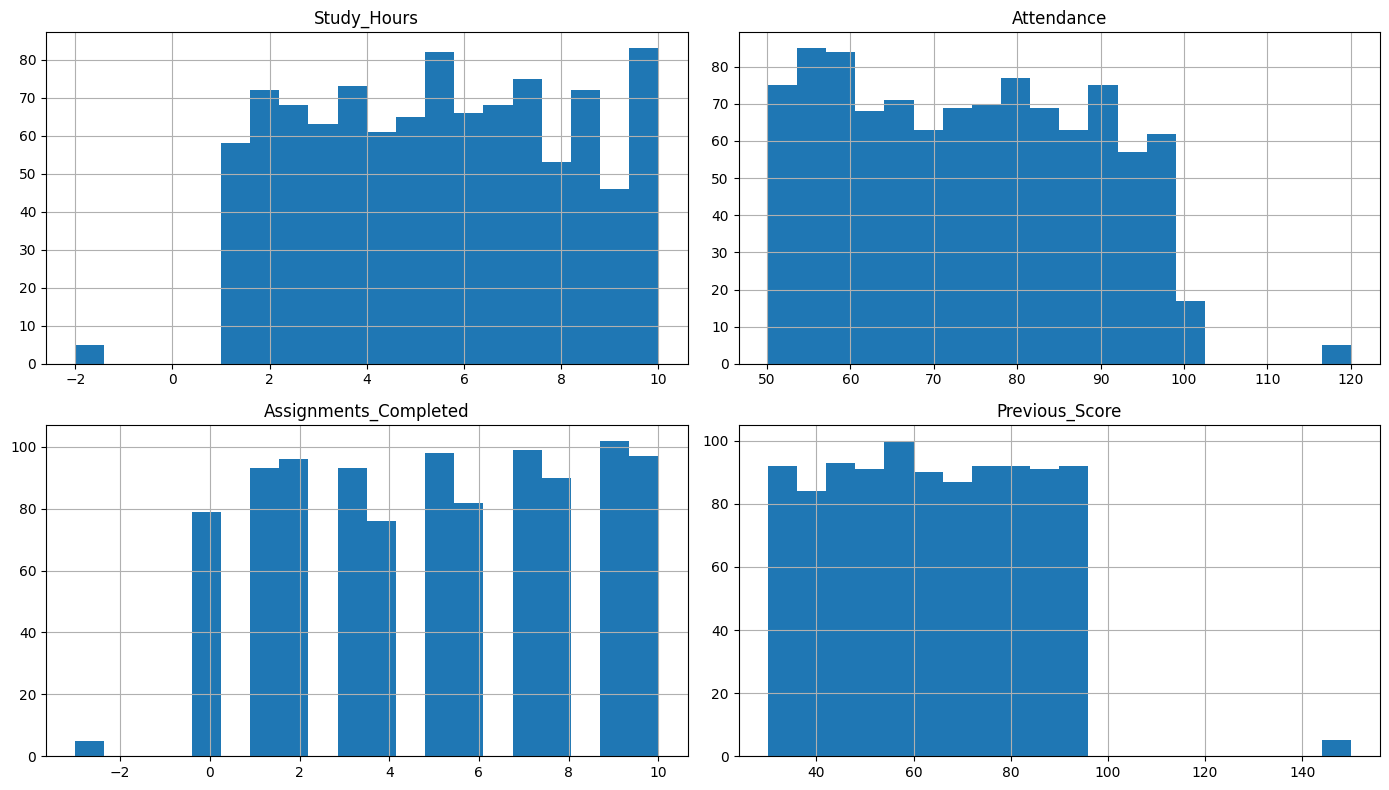

In [37]:
# Histograms

# Visualizing all columns in independant variables as well as dependant variable

# Numerical_Columns/ Independant_Variables = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Categorical_Columns/ Dependant_Variables = ["Result"]

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

data[Numerical_Columns].hist(figsize = (14,8), bins = 20)

plt.tight_layout()
plt.show()

# Histograms help us understand the distribution of numerical features.

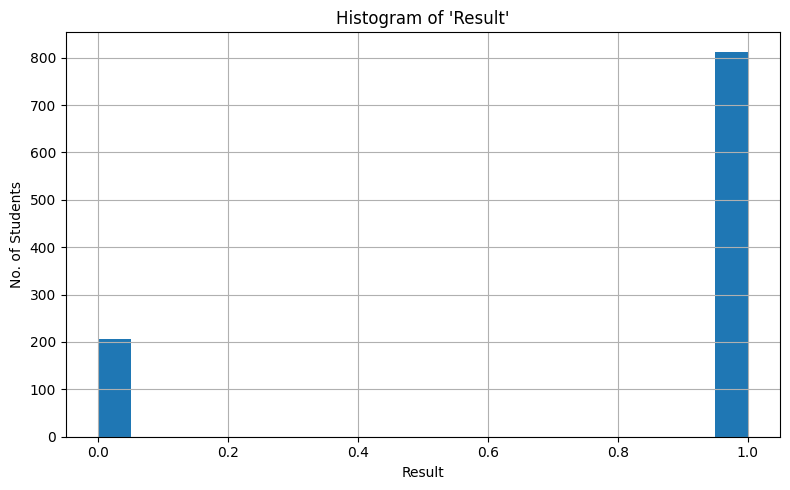

In [38]:
# Categorical_Columns/ Dependant_Variable = ["Result"]

Categorical_Columns = ["Result"]

data[Categorical_Columns].hist(figsize = (8, 5), bins = 20)

plt.title("Histogram of 'Result'")
plt.xlabel("Result")
plt.ylabel("No. of Students")

plt.tight_layout()
plt.show()

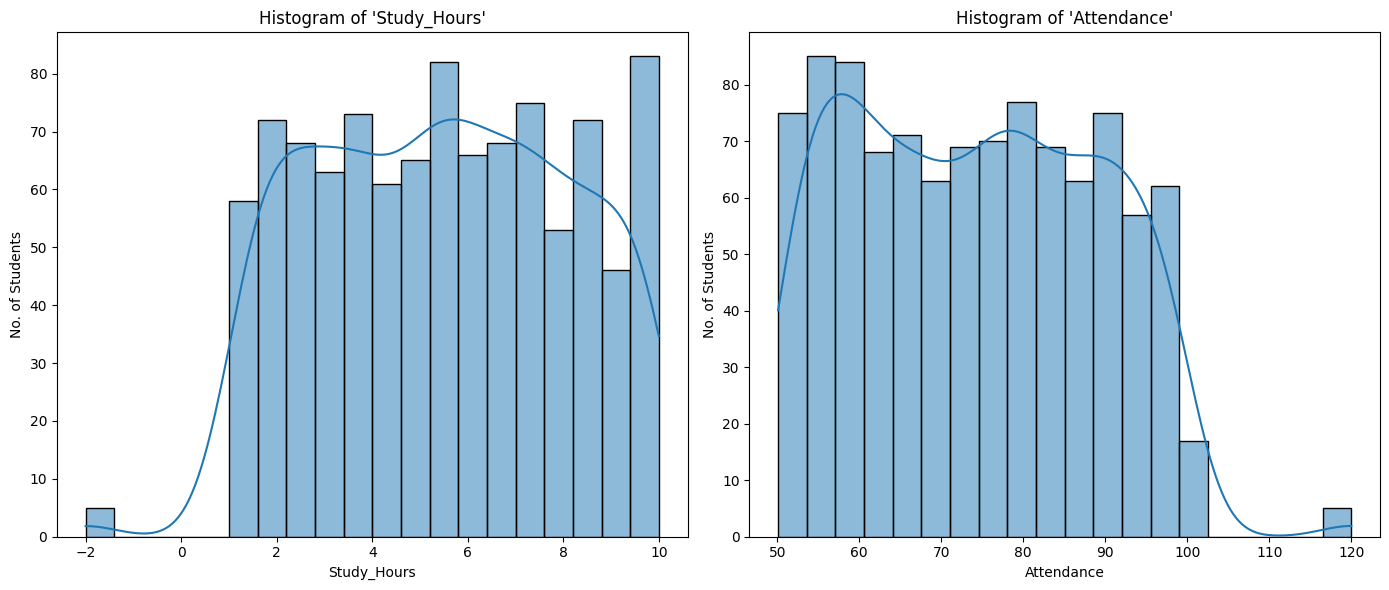

In [39]:
# Histograms (Individual Histograms for Independant_Features/ Numerical_Columns)

# Independant_Features/ Numerical_Columns
# Dependant_Features/ Categorical_Columns/ Target Variable

# Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Categorical_Columns = ["Result"]

# "Study_Hours"

plt.figure(figsize = (14,6))

plt.subplot(1, 2, 1)
sns.histplot(data["Study_Hours"], bins = 20, kde = True)

plt.title("Histogram of 'Study_Hours'")
plt.xlabel("Study_Hours")
plt.ylabel("No. of Students")

# "Attendance"

plt.subplot(1, 2, 2)
sns.histplot(data["Attendance"], bins = 20, kde = True)

plt.title("Histogram of 'Attendance'")
plt.xlabel("Attendance")
plt.ylabel("No. of Students")

plt.tight_layout()
plt.show()

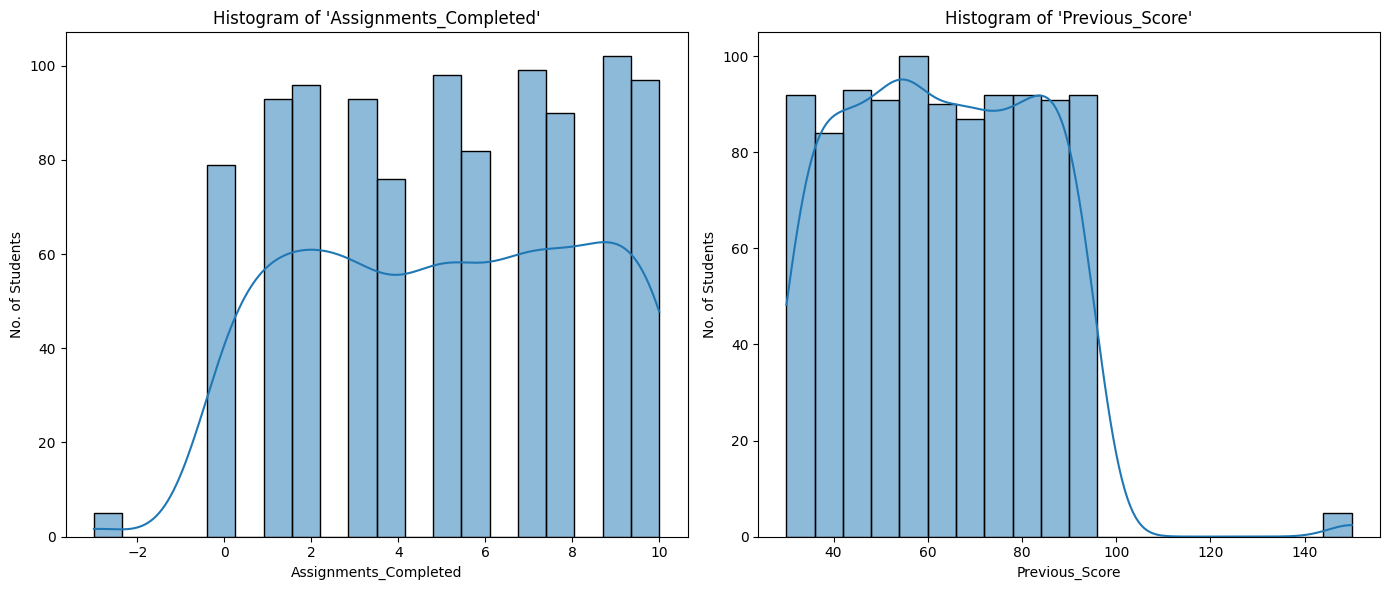

In [40]:
# "Assignments_Completed"

plt.figure(figsize = (14,6))

plt.subplot(1, 2, 1)
sns.histplot(data["Assignments_Completed"], bins = 20, kde = True)

plt.title("Histogram of 'Assignments_Completed'")
plt.xlabel("Assignments_Completed")
plt.ylabel("No. of Students")

# "Previous_Score"

plt.subplot(1, 2, 2)
sns.histplot(data["Previous_Score"], bins = 20, kde = True)

plt.title("Histogram of 'Previous_Score'")
plt.xlabel("Previous_Score")
plt.ylabel("No. of Students")

plt.tight_layout()
plt.show()

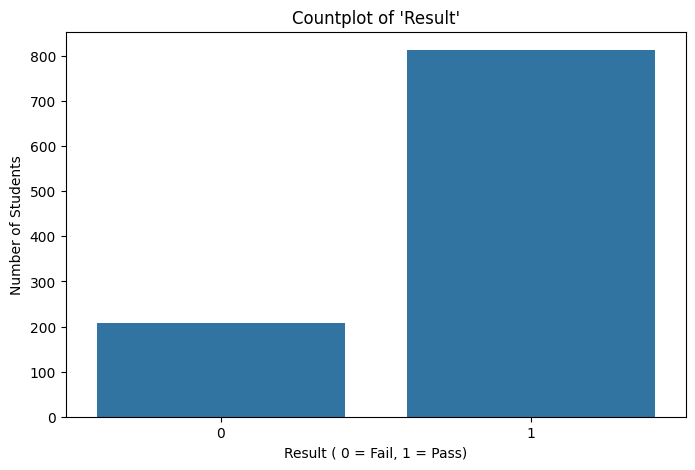

In [41]:
# Countplot

# Target Distribution - Countplot for target variable (i.e) data["Result"]

Categorical_Columns = ["Result"]

plt.figure(figsize = (8,5))

sns.countplot(data = data, x = "Result")

plt.title("Countplot of 'Result'")
plt.xlabel("Result ( 0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()

In [42]:
# Individual count for "Result" (0 = Fail, 1 = Pass)

print("Target Distribution of Result:")
print(data["Result"].value_counts())

# Percentage value for "Result" (0 = Fail, 1 = Pass)

print("\n")
print("Percentage Distribution of Result")
print(data["Result"].value_counts(normalize = True) * 100)

Target Distribution of Result:
Result
1    813
0    207
Name: count, dtype: int64


Percentage Distribution of Result
Result
1    79.705882
0    20.294118
Name: proportion, dtype: float64


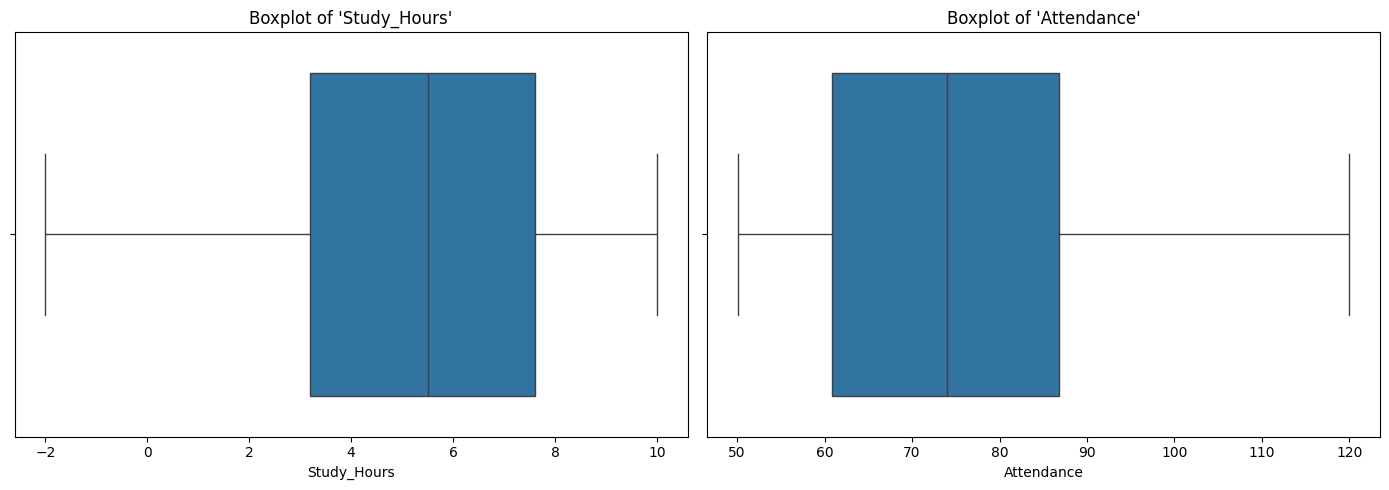

In [43]:
# Boxplots (Individual Boxplots for Independant_Features/ Numerical_Columns)

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

# "Study_Hours"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = data["Study_Hours"])

plt.title("Boxplot of 'Study_Hours'")
plt.xlabel("Study_Hours")

# "Attendance"

plt.subplot(1, 2, 2)
sns.boxplot(x = data["Attendance"])

plt.title("Boxplot of 'Attendance'")
plt.xlabel("Attendance")

plt.tight_layout()
plt.show()

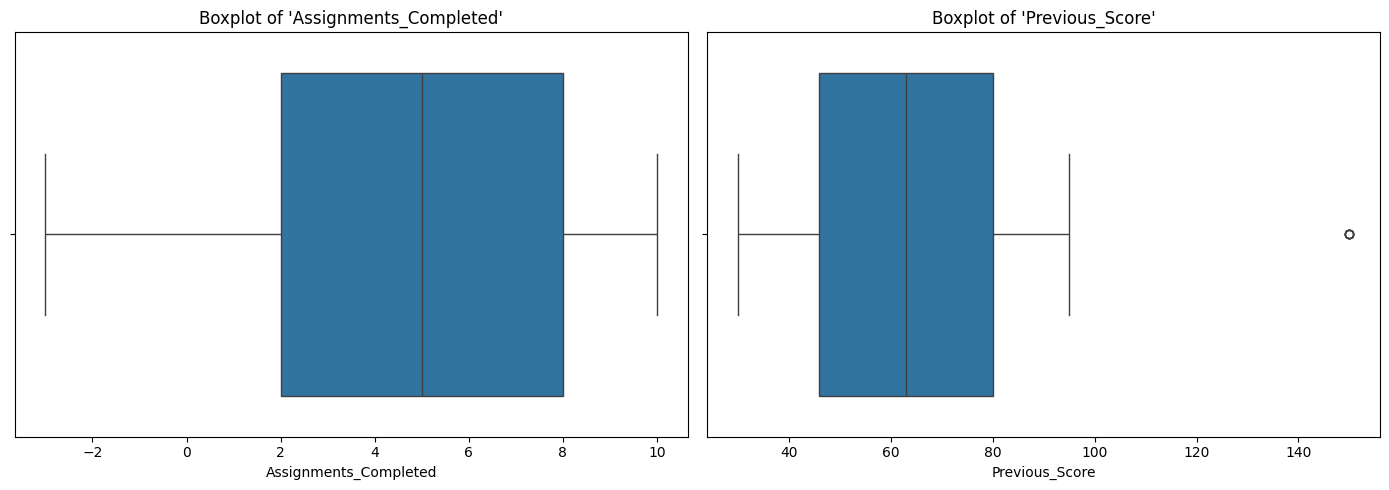

In [44]:
# "Assignments_Completed"

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.boxplot(x = data["Assignments_Completed"])

plt.title("Boxplot of 'Assignments_Completed'")
plt.xlabel("Assignments_Completed")

# "Previous_Score"

plt.subplot(1, 2, 2)
sns.boxplot(x = data["Previous_Score"])

plt.title("Boxplot of 'Previous_Score'")
plt.xlabel("Previous_Score")

plt.tight_layout()
plt.show()

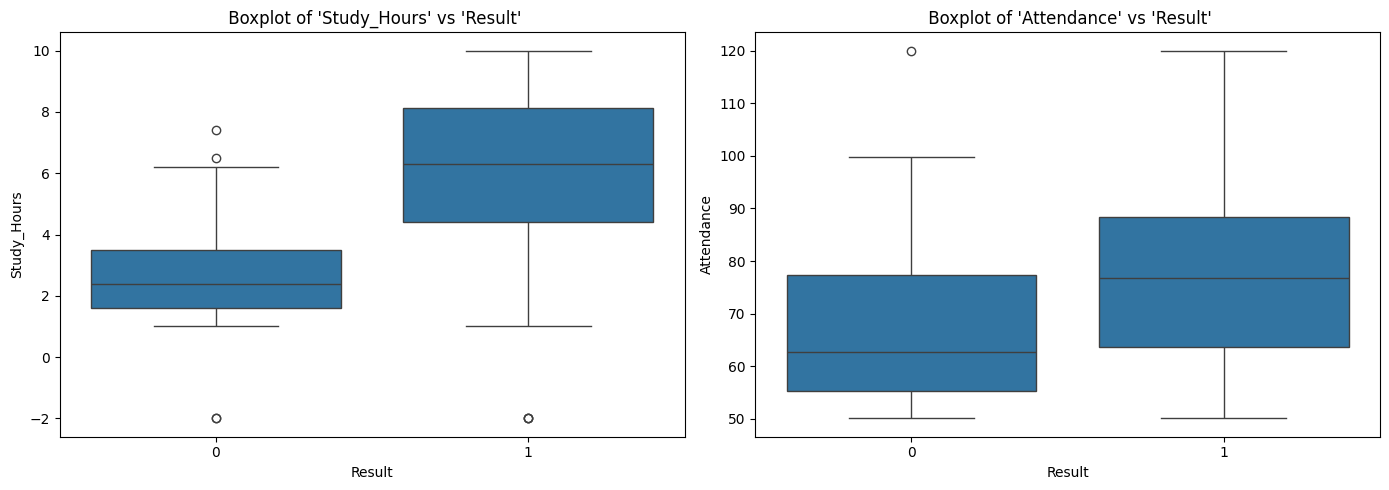

In [45]:
# Boxplot distribution w.r.t Independant Features/ Numerical_Columns and Dependant Features/ Cateogorical Columns

# Independant_Features/ Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Dependant_Features/ Categorical_Columns = ["Result"]

# "Study_Hours" vs "Result"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = "Result",
            y = "Study_Hours",
            data = data)

plt.title(" Boxplot of 'Study_Hours' vs 'Result'")

# "Attendance" vs "Result"

plt.subplot(1,2,2)
sns.boxplot(x = "Result",
            y = "Attendance",
            data = data)

plt.title(" Boxplot of 'Attendance' vs 'Result'")

plt.tight_layout()
plt.show()

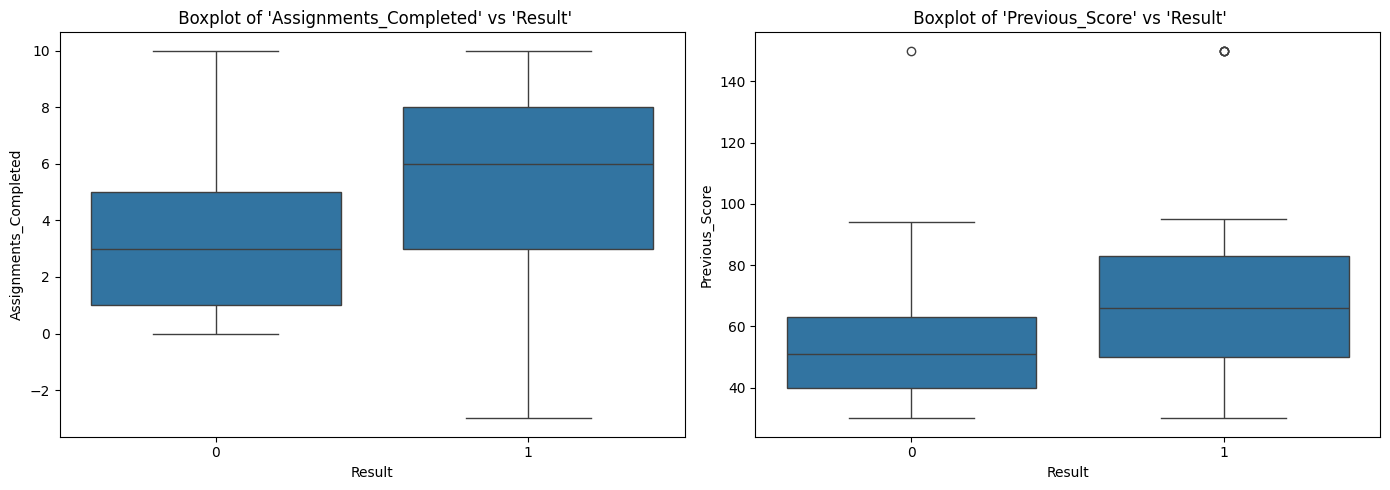

In [46]:
# "Assignments_Completed" vs "Result"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = "Result",
            y = "Assignments_Completed",
            data = data)

plt.title(" Boxplot of 'Assignments_Completed' vs 'Result'")

# "Previous_Score" vs "Result"

plt.subplot(1,2,2)
sns.boxplot(x = "Result",
            y = "Previous_Score",
            data = data)

plt.title(" Boxplot of 'Previous_Score' vs 'Result'")

plt.tight_layout()
plt.show()

In [47]:
# All averages w.r.t Dependant_Features/ Target_Variables/ Categorical_Columns

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

pd.set_option("display.width", 200)
print(data.groupby("Result")[Numerical_Columns].mean())

        Study_Hours  Attendance  Assignments_Completed  Previous_Score
Result                                                                
0          2.626214   67.071359               3.219512       53.346341
1          6.158955   76.050871               5.560248       65.605721


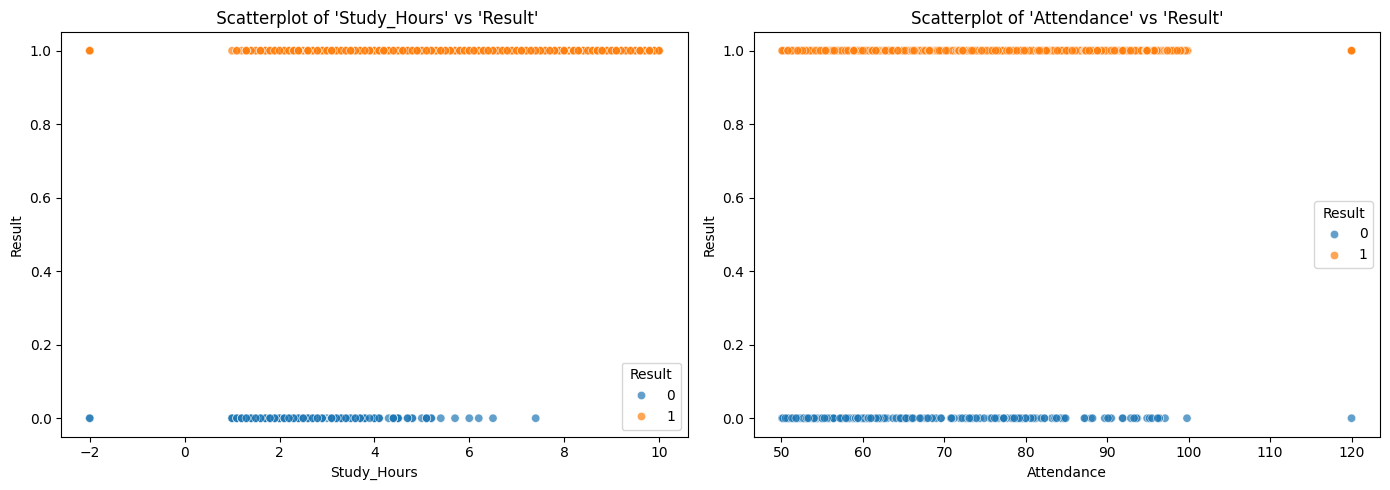

In [48]:
# Scatterplots

plt.figure(figsize = (14,5))

# "Study_Hours" vs "Result"

plt.subplot(1, 2, 1)

sns.scatterplot(data = data, x = "Study_Hours", y = "Result", hue = "Result", alpha = 0.7)

plt.title(" Scatterplot of 'Study_Hours' vs 'Result'")
plt.xlabel("Study_Hours")
plt.ylabel("Result")

# "Attendance" vs "Result"

plt.subplot(1, 2, 2)

sns.scatterplot(data = data, x = "Attendance", y = "Result", hue = "Result", alpha = 0.7)

plt.title("Scatterplot of 'Attendance' vs 'Result'")
plt.xlabel("Attendance")
plt.ylabel("Result")

plt.tight_layout()
plt.show()

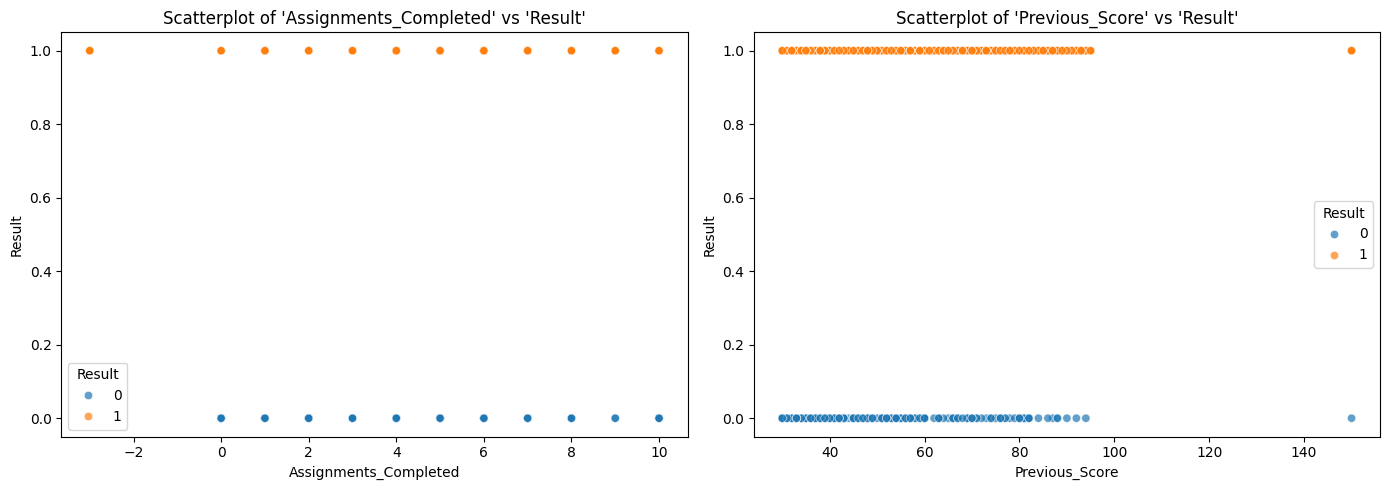

In [49]:
# "Assignments_Completed" vs "Result"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)

sns.scatterplot(data = data, x = "Assignments_Completed", y = "Result", hue = "Result", alpha = 0.7)

plt.title("Scatterplot of 'Assignments_Completed' vs 'Result'")
plt.xlabel("Assignments_Completed")
plt.ylabel("Result")

# "Previous_Score" vs "Result"

plt.subplot(1, 2, 2)

sns.scatterplot(data = data, x = "Previous_Score", y = "Result", hue = "Result", alpha = 0.7)

plt.title("Scatterplot of 'Previous_Score' vs 'Result'")
plt.xlabel("Previous_Score")
plt.ylabel("Result")

plt.tight_layout()
plt.show()

In [50]:
# Correlation Matrix & Heatmap

correlation_matrix = data.corr(numeric_only = True)

correlation_matrix

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
Study_Hours,1.000000,-0.003532,-0.010865,0.091284,0.542039
Attendance,-0.003532,1.000000,-0.033995,-0.030131,0.244777
Assignments_Completed,-0.010865,-0.033995,1.000000,0.001784,0.292933
Previous_Score,0.091284,-0.030131,0.001784,1.000000,0.246984
Result,0.542039,0.244777,0.292933,0.246984,1.000000


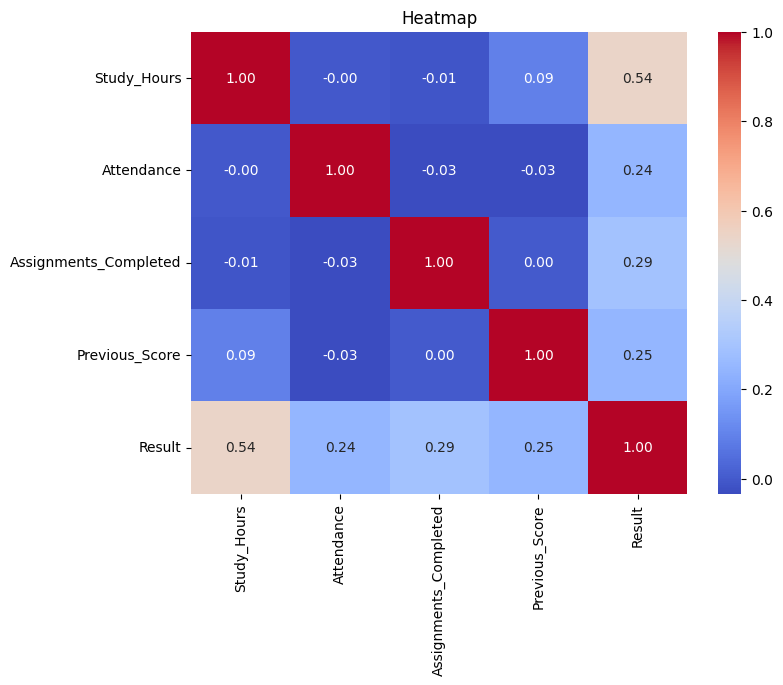

In [51]:
# Creating Heatmap for the Correlation Matrix

plt.figure(figsize = (8,6))

sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")

plt.title("Heatmap")

plt.show()

In [52]:
# Correlation of each independant feature/ Numerical_Columns w.r.t Dependant_Features/ Target_Variables/ Categorical_Columns

# Study_Hours	0.54
# Attendance	0.24
# Assignments_Completed	0.29
# Previous_Score	0.25

In [53]:
# Clean invalid values

# Invalid Study_Hours

data.loc[data["Study_Hours"] < 0, "Study_Hours"] = np.nan

# Invalid Attendance

data.loc[(data["Attendance"] < 0) | (data["Attendance"] > 100), "Attendance"] = np.nan

# Invalid Assignments_Completed

data.loc[data["Assignments_Completed"] < 0, "Assignments_Completed"] = np.nan

# Invalid Previous_Score

data.loc[(data["Previous_Score"] < 0) | (data["Previous_Score"] > 100), "Previous_Score"] = np.nan

In [54]:
# Check invalid values now -

# We get total null values = missing values + invalid values now turned to null.
# Missing values (null) according to each column were 10,10,10,11 and invalid values according to each column were 5,5,5,5.

# Hence, now the total missing values -

print(data.isnull().sum())

Study_Hours              15
Attendance               15
Assignments_Completed    15
Previous_Score           16
Result                    0
dtype: int64


In [55]:
# Handle total missing values (total null) with median.

# Median imputation is a simple and robust approach to handle small no. of missing values.

data2 = data.copy()

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

data2[Numerical_Columns] = data2[Numerical_Columns].fillna(data2[Numerical_Columns].median())

In [56]:
data2

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,5.0,56.0,1
4,1.1,55.9,2.0,82.0,0
...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0


In [57]:
# Check for total missing values

data2.isnull().sum()

,0
Study_Hours,0
Attendance,0
Assignments_Completed,0
Previous_Score,0
Result,0


In [58]:
# Hence, process for total missing (null) values is now complete.

In [59]:
# Check for duplicates

print(data2.duplicated().sum())

# Shape of dataset before dropping duplicates (original dataset)

print(data2.shape)

20
(1020, 5)


In [60]:
# Now, remove duplicates

data2.drop_duplicates(inplace = True)

In [61]:
# Check new data

data2

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,5.0,56.0,1
4,1.1,55.9,2.0,82.0,0
...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0


In [62]:
# Hence, now after dropping duplicates -

print("No. of Rows & Columns in new dataset:", data2.shape)

No. of Rows & Columns in new dataset: (1000, 5)


In [63]:
# Outlier Detection & Removal

# IQR method

# IQR = Q3 - Q1

# Lower bound: Q1 - 1.5 × IQR
# Upper bound: Q3 + 1.5 × IQR`

# Values outside these limits are considered statistical outliers.

In [64]:
Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

IQR_Summary = []

# Compute bounds for Numerical_Columns

Q1 = data2[Numerical_Columns].quantile(0.25)
Q3 = data2[Numerical_Columns].quantile(0.75)

IQR = Q3 - Q1

lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

# Build mask across all columns

Outlier_Mask = (data2[Numerical_Columns] < lower_bounds) | (data2[Numerical_Columns] > upper_bounds)

# Remove rows with outliers in ANY column

data3 = data2[~Outlier_Mask.any(axis = 1)]

In [65]:
# Print this new data

data3

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,5.0,56.0,1
4,1.1,55.9,2.0,82.0,0
...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1
1016,6.8,61.6,6.0,93.0,1
1017,5.4,73.4,10.0,57.0,1
1018,2.8,93.3,0.0,42.0,0


In [66]:
# Also,

display(Outlier_Mask)

,Study_Hours,Attendance,Assignments_Completed,Previous_Score
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
1015,False,False,False,False
1016,False,False,False,False
1017,False,False,False,False
1018,False,False,False,False


In [67]:
print("No. of outliers in each column:\n")
print(Outlier_Mask.sum())

No. of outliers in each column:

Study_Hours              0
Attendance               0
Assignments_Completed    0
Previous_Score           0
dtype: int64


In [68]:
# Steps

# 1. # data2[Numerical_Columns] - This selects only the numeric columns you listed:

                                # ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"].

                                # The result is a DataFrame with just those four columns.


# 2. # < lower_bounds and > upper_bounds

     # lower_bounds and upper_bounds are Series (one bound per column).

     # Pandas automatically aligns each column with its corresponding bound.

     # So for each cell in the DataFrame, it checks:

     # Is the value less than that column’s lower bound?

     # Is the value greater than that column’s upper bound?


# 3. # | (bitwise OR)

     # Combines the two conditions.

     # Result: a Boolean DataFrame with the same shape as your numeric columns.

     # Each cell is True if it’s an outlier, False otherwise.


# 4. # Outlier_Mask.any(axis = 1)

     # Collapses each row into a single True/False.

     # True if the row has an outlier in any of the four columns.

     # False if the row has no outliers at all.

# 5. # ~Outlier_Mask.any(axis = 1)

     # Flips the result.

     # Now True means “row is clean” (no outliers).

     # False means “row has at least one outlier”.

# 6. # data2[...]

     # Applies that mask row‑wise.

     # Keeps all columns intact, but drops rows with outliers.

In [69]:
# Feature Engineering

# Feature 1 — 'Performance_Index' --> We can combine 'Attendance' and 'Previous_Score' into a simple overall performance indicator.

# This represents a simple combination of: Attendance & Previous_Score

In [70]:
# Feature 1

data3["Performance_Index"] = (data3["Attendance"] + data3["Previous_Score"]) / 2

data3

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index
0,6.3,84.1,0.0,83.0,1,83.55
1,2.6,50.3,4.0,76.0,0,63.15
2,8.8,65.3,7.0,92.0,1,78.65
3,6.8,99.3,5.0,56.0,1,77.65
4,1.1,55.9,2.0,82.0,0,68.95
...,...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1,78.00
1016,6.8,61.6,6.0,93.0,1,77.30
1017,5.4,73.4,10.0,57.0,1,65.20
1018,2.8,93.3,0.0,42.0,0,67.65


In [71]:
# Feature 2 — 'Study_Engagement' --> We can combine 'Study_Hours' and 'Assignments_Completed'.

# This gives us a simple measure representing academic effort.

data3["Study_Engagement"] = (data3["Study_Hours"] + data3["Assignments_Completed"])

data3

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index,Study_Engagement
0,6.3,84.1,0.0,83.0,1,83.55,6.3
1,2.6,50.3,4.0,76.0,0,63.15,6.6
2,8.8,65.3,7.0,92.0,1,78.65,15.8
3,6.8,99.3,5.0,56.0,1,77.65,11.8
4,1.1,55.9,2.0,82.0,0,68.95,3.1
...,...,...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1,78.00,12.7
1016,6.8,61.6,6.0,93.0,1,77.30,12.8
1017,5.4,73.4,10.0,57.0,1,65.20,15.4
1018,2.8,93.3,0.0,42.0,0,67.65,2.8


In [72]:
# Inspect the new features

# Print the dataset after feature engineering -

data3

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index,Study_Engagement
0,6.3,84.1,0.0,83.0,1,83.55,6.3
1,2.6,50.3,4.0,76.0,0,63.15,6.6
2,8.8,65.3,7.0,92.0,1,78.65,15.8
3,6.8,99.3,5.0,56.0,1,77.65,11.8
4,1.1,55.9,2.0,82.0,0,68.95,3.1
...,...,...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1,78.00,12.7
1016,6.8,61.6,6.0,93.0,1,77.30,12.8
1017,5.4,73.4,10.0,57.0,1,65.20,15.4
1018,2.8,93.3,0.0,42.0,0,67.65,2.8


In [73]:
# This is our fully cleaned dataset along with feature engineering.

# Recheck the dataset -

print("No. of Rows & Columns in cleaned dataset:", data3.shape)
print("No. of missing values in the cleaned dataset:", data3.isnull().sum().sum())
print("No. of duplicate rows in the cleaned dataset:", data3.duplicated().sum())

No. of Rows & Columns in cleaned dataset: (1000, 7)
No. of missing values in the cleaned dataset: 0
No. of duplicate rows in the cleaned dataset: 0


In [74]:
# Recheck for invalid values -

print("Invalid 'Study_Hours':", (data3["Study_Hours"] < 0).sum())

print("Invalid 'Attendance':", ((data3["Attendance"] < 0) | (data3["Attendance"] > 100)).sum())

print("Invalid 'Assignments_Completed':", (data3["Assignments_Completed"] < 0).sum())

print("Invalid 'Previous_Score':", ((data3["Previous_Score"] < 0) | (data3["Previous_Score"] > 100)).sum())

Invalid 'Study_Hours': 0
Invalid 'Attendance': 0
Invalid 'Assignments_Completed': 0
Invalid 'Previous_Score': 0


In [75]:
# All values are 0 for missing, duplicate and invalid values in the dataset.

In [76]:
# Show this cleaned dataset -

data3

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index,Study_Engagement
0,6.3,84.1,0.0,83.0,1,83.55,6.3
1,2.6,50.3,4.0,76.0,0,63.15,6.6
2,8.8,65.3,7.0,92.0,1,78.65,15.8
3,6.8,99.3,5.0,56.0,1,77.65,11.8
4,1.1,55.9,2.0,82.0,0,68.95,3.1
...,...,...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,1,78.00,12.7
1016,6.8,61.6,6.0,93.0,1,77.30,12.8
1017,5.4,73.4,10.0,57.0,1,65.20,15.4
1018,2.8,93.3,0.0,42.0,0,67.65,2.8


In [77]:
# Shape of this new dataset

print(data3.shape)

(1000, 7)


In [78]:
# Columns in the new dataset

print(data3.columns.to_list())

['Study_Hours', 'Attendance', 'Assignments_Completed', 'Previous_Score', 'Result', 'Performance_Index', 'Study_Engagement']


In [79]:
# Datatypes in the new dataset

print("Datatypes in the dataset:\n")
print(data3.dtypes)

Datatypes in the dataset:

Study_Hours              float64
Attendance               float64
Assignments_Completed    float64
Previous_Score           float64
Result                     int64
Performance_Index        float64
Study_Engagement         float64
dtype: object


In [80]:
# Basic information

print(data3.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            1000 non-null   float64
 1   Attendance             1000 non-null   float64
 2   Assignments_Completed  1000 non-null   float64
 3   Previous_Score         1000 non-null   float64
 4   Result                 1000 non-null   int64  
 5   Performance_Index      1000 non-null   float64
 6   Study_Engagement       1000 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 62.5 KB
None


In [81]:
# Basic statistics

data3.describe()

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index,Study_Engagement
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.470100,73.905200,5.125000,62.523000,0.795000,68.214100,10.595100
std,2.569018,14.324716,3.152668,18.936474,0.403904,11.835756,4.060689
min,1.000000,50.100000,0.000000,30.000000,0.000000,40.550000,1.100000
25%,3.300000,60.975000,2.000000,46.000000,1.000000,59.700000,7.500000
50%,5.500000,73.900000,5.000000,63.000000,1.000000,67.925000,10.700000
75%,7.525000,86.325000,8.000000,79.000000,1.000000,76.862500,13.400000
max,10.000000,99.900000,10.000000,95.000000,1.000000,96.650000,20.000000


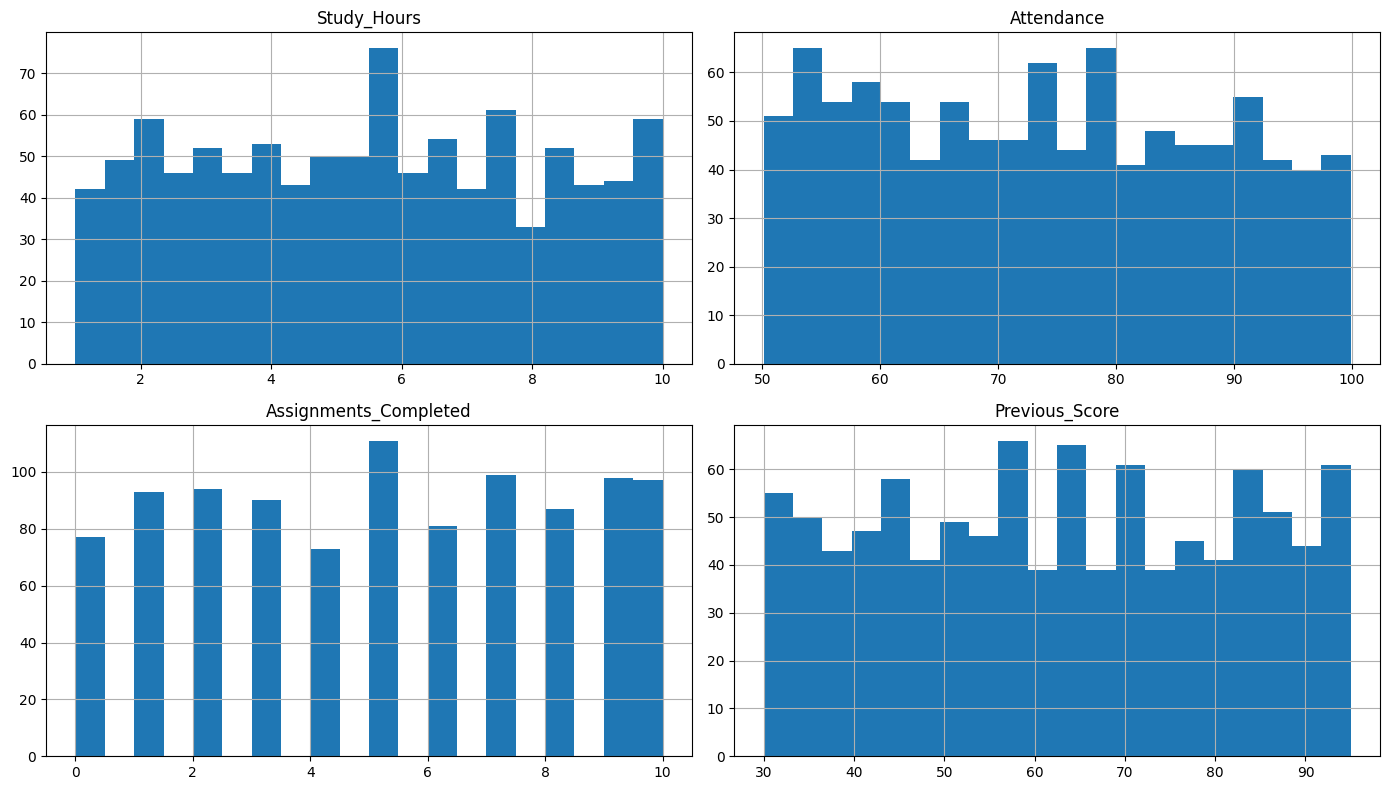

In [82]:
# Visualization of cleaned dataset

# Grouped Histograms


# Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]
# Categorical_Columns = ["Result"]

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

data3[Numerical_Columns].hist(figsize = (14, 8), bins = 20)

plt.tight_layout()
plt.show()

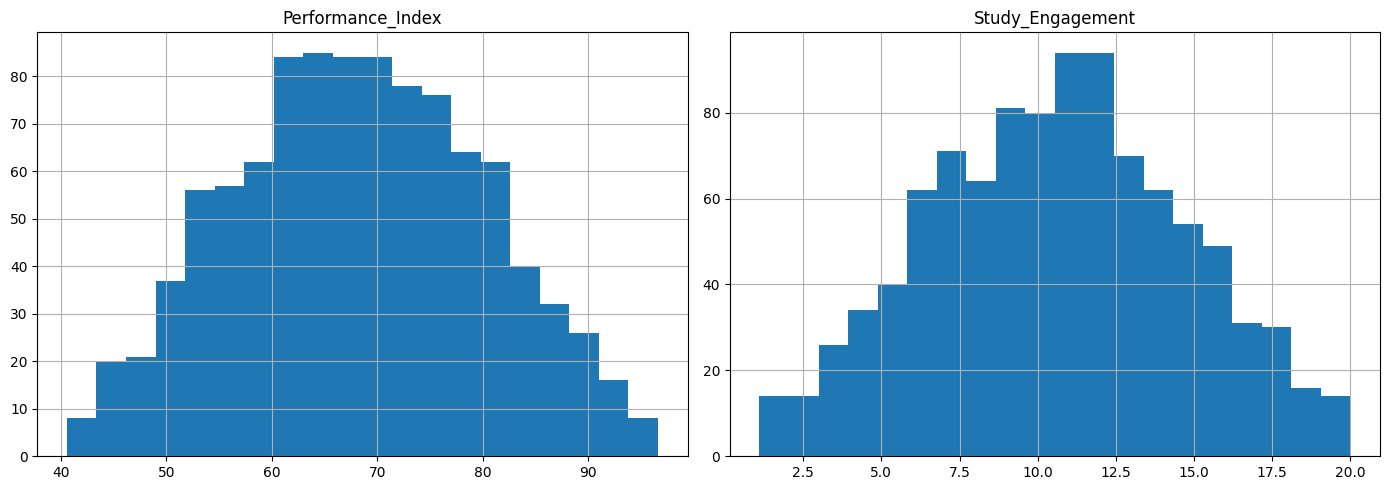

In [83]:
# Engineered Columns

Engineered_Columns = ["Performance_Index", "Study_Engagement"]

data3[Engineered_Columns].hist(figsize = (14, 5), bins = 20)

plt.tight_layout()
plt.show()

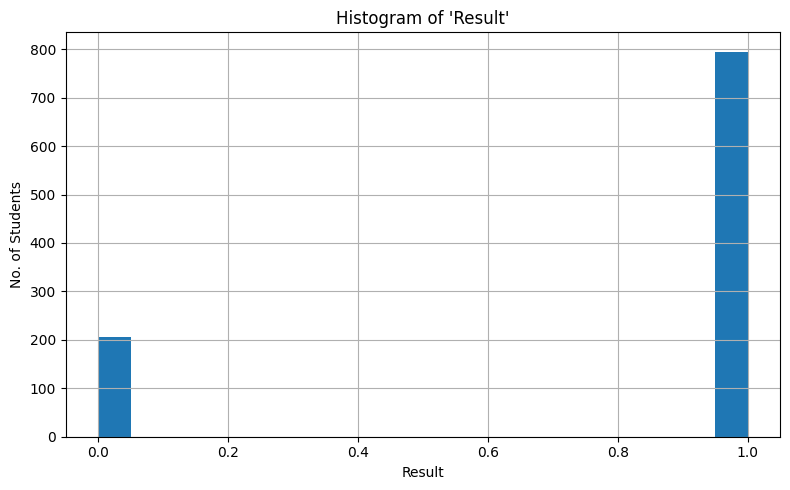

In [84]:
# Target

# Categorical_Columns/ Dependant_Feature = ["Result"]

Categorical_Columns = ["Result"]

data3["Result"].hist(figsize = (8,5), bins = 20)

plt.title("Histogram of 'Result'")
plt.xlabel("Result")
plt.ylabel("No. of Students")

plt.tight_layout()
plt.show()

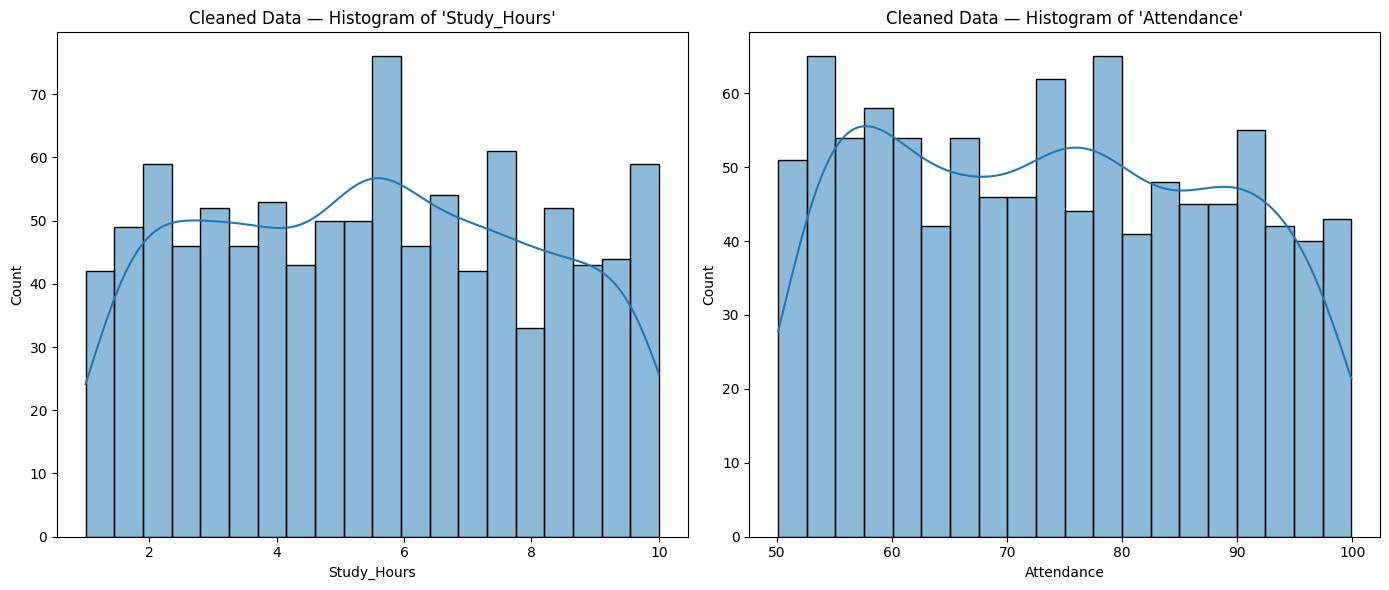

In [85]:
# Individual Histograms (Individual Histograms for Independant_Features/ Numerical_Columns and Engineered_Columns/ Features)

# Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]
# Categorical_Columns = ["Result"]

# Study_Hours

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data3, x = "Study_Hours", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Study_Hours'")
plt.xlabel("Study_Hours")

# "Attendance"

plt.subplot(1,2,2)
sns.histplot(data = data3, x = "Attendance", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Attendance'")
plt.xlabel("Attendance")

plt.tight_layout()
plt.show()

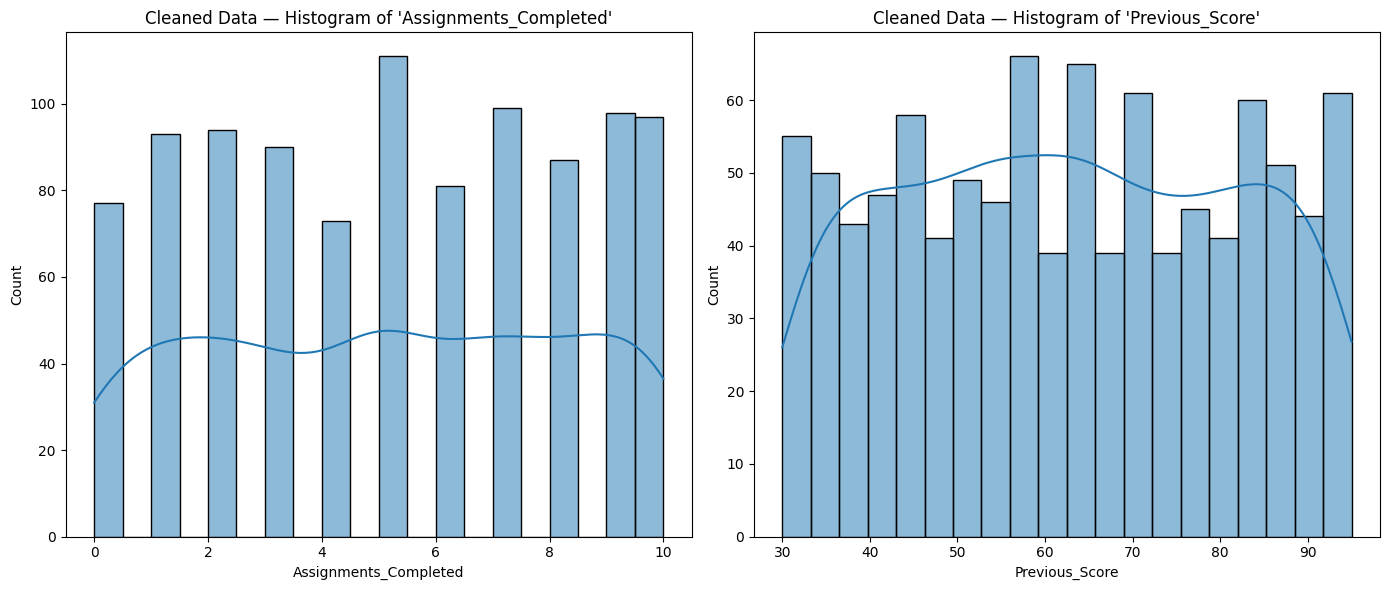

In [86]:
# "Assignments_Completed"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data3, x = "Assignments_Completed", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Assignments_Completed'")
plt.xlabel("Assignments_Completed")

# "Previous_Score"

plt.subplot(1,2,2)
sns.histplot(data = data3, x = "Previous_Score", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Previous_Score'")
plt.xlabel("Previous_Score")

plt.tight_layout()
plt.show()

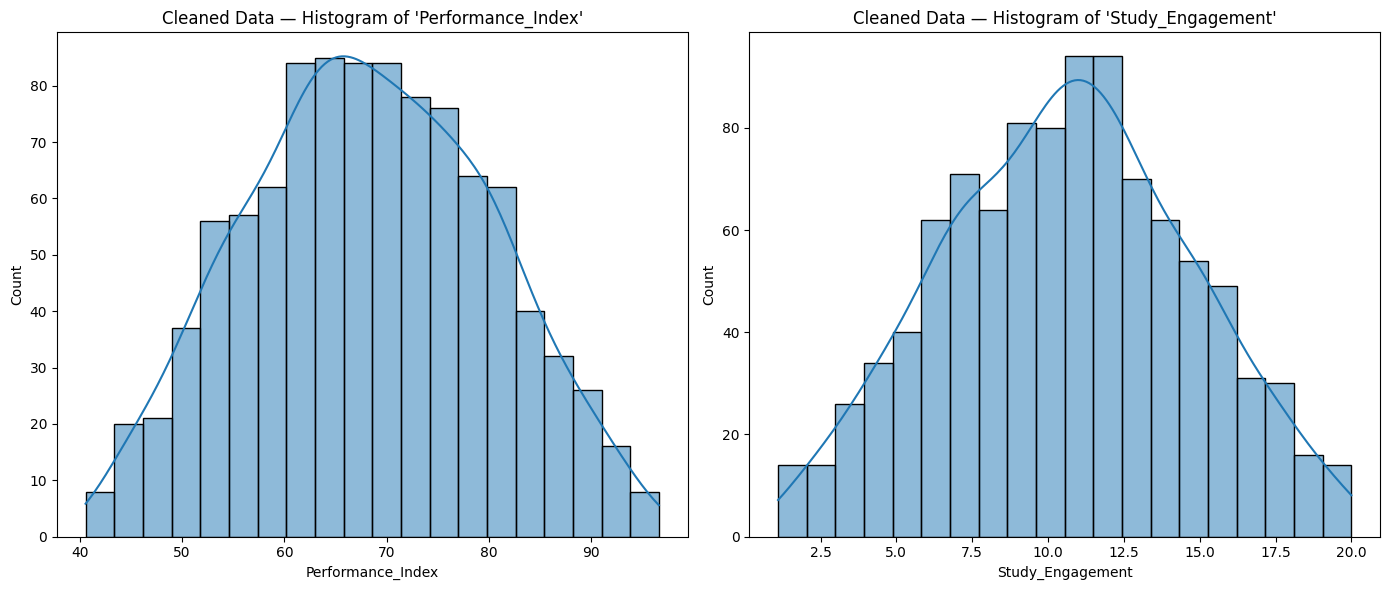

In [87]:
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]

Engineered_Columns = ["Performance_Index", "Study_Engagement"]

# "Performance_Index"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data3, x = "Performance_Index", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Performance_Index'")
plt.xlabel("Performance_Index")

# "Study_Engagement"

plt.subplot(1,2,2)
sns.histplot(data = data3, x = "Study_Engagement", bins = 20, kde = True)

plt.title("Cleaned Data — Histogram of 'Study_Engagement'")
plt.xlabel("Study_Engagement")

plt.tight_layout()
plt.show()

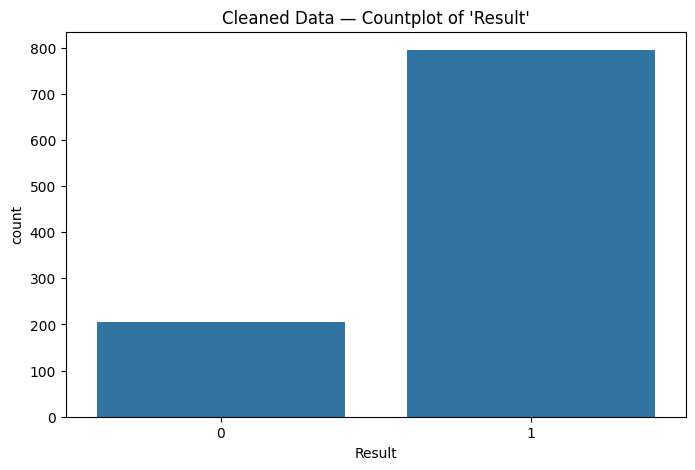

In [88]:
# Countplot

# Target Distribution - Countplot of Target - Dependant_Features/ Target Variables/ Categorical_Columns

# Categorical_Columns = ["Result"]

Categorical_Columns = ["Result"]

plt.figure(figsize = (8, 5))

sns.countplot(x = data3["Result"])

plt.title("Cleaned Data — Countplot of 'Result'")
plt.xlabel("Result")

plt.show()

In [89]:
# Individual count for "Result" (0 = Fail, 1 = Pass)

print("Target Distribution of Result:")
print(data3["Result"].value_counts())

# Percentage value for "Result" (0 = Fail, 1 = Pass)

print("\n")
print("Percentage Distribution of Result")
print(data3["Result"].value_counts(normalize = True) * 100)

Target Distribution of Result:
Result
1    795
0    205
Name: count, dtype: int64


Percentage Distribution of Result
Result
1    79.5
0    20.5
Name: proportion, dtype: float64


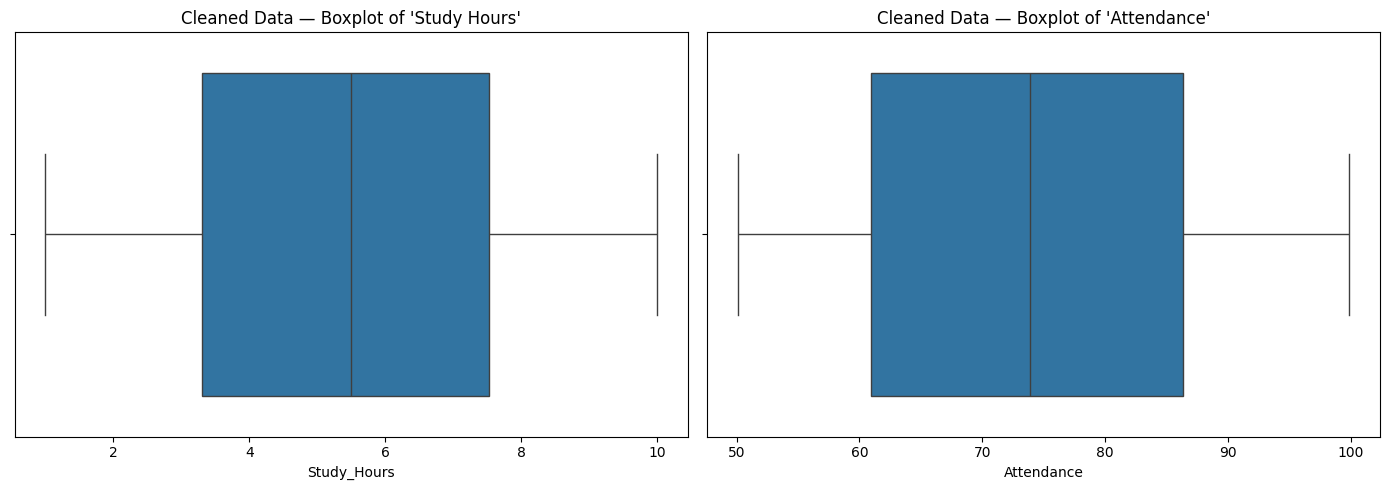

In [90]:
# Boxplots (Individual Boxplots for Independant_Features/ Numerical_Columns and Engineered_Columns/ Features)

# Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]
# Categorical_Columns = ["Result"]

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

# "Study_Hours"

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.boxplot(x = data3["Study_Hours"])

plt.title("Cleaned Data — Boxplot of 'Study Hours'")
plt.xlabel("Study_Hours")

# "Attendance"

plt.subplot(1,2,2)
sns.boxplot(x = data3["Attendance"])

plt.title("Cleaned Data — Boxplot of 'Attendance'")
plt.xlabel("Attendance")

plt.tight_layout()
plt.show()

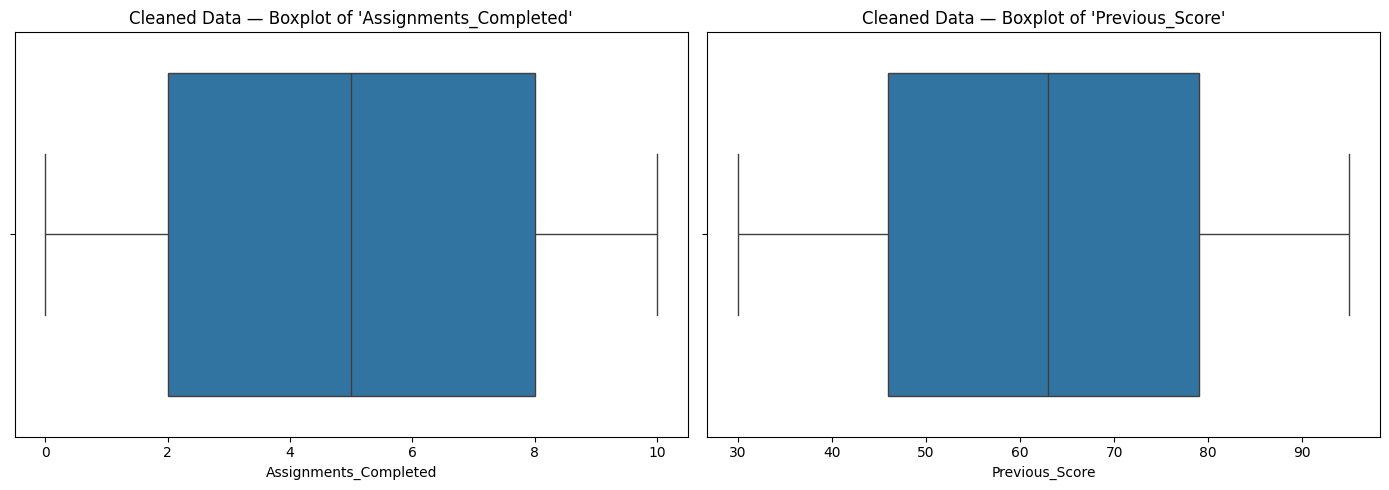

In [91]:
# "Assignments_Completed"

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.boxplot(x = data3["Assignments_Completed"])

plt.title("Cleaned Data — Boxplot of 'Assignments_Completed'")
plt.xlabel("Assignments_Completed")

# "Previous_Score"

plt.subplot(1,2,2)
sns.boxplot(x = data3["Previous_Score"])

plt.title("Cleaned Data — Boxplot of 'Previous_Score'")
plt.xlabel("Previous_Score")

plt.tight_layout()
plt.show()

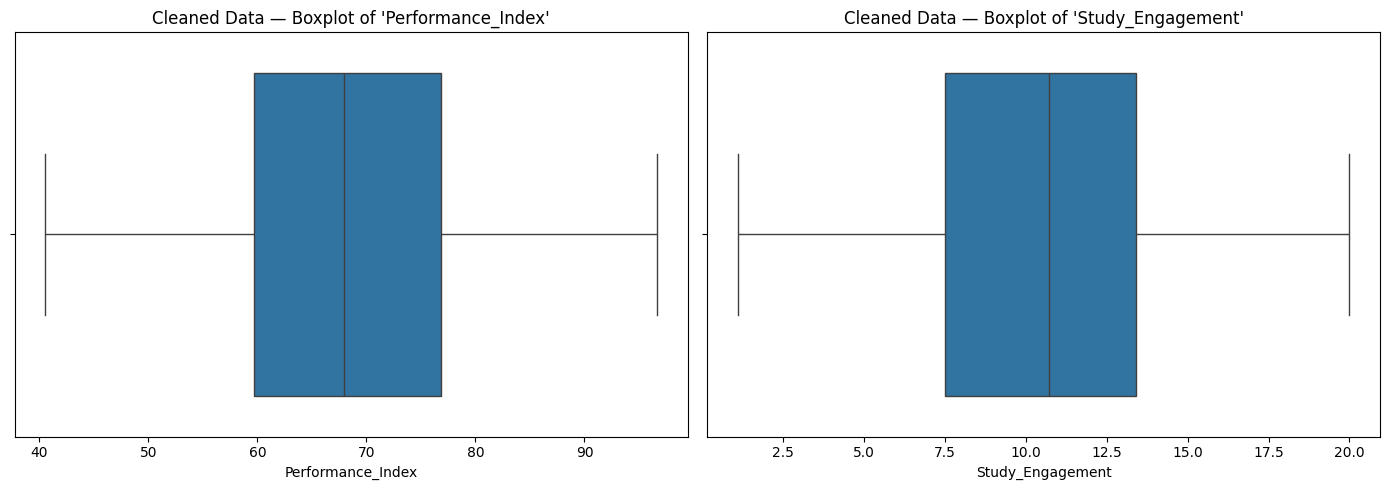

In [92]:
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]

Engineered_Columns = ["Performance_Index", "Study_Engagement"]

# "Performance_Index"

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.boxplot(x = data3["Performance_Index"])

plt.title("Cleaned Data — Boxplot of 'Performance_Index'")
plt.xlabel("Performance_Index")

# "Study_Engagement"

plt.subplot(1,2,2)
sns.boxplot(x = data3["Study_Engagement"])

plt.title("Cleaned Data — Boxplot of 'Study_Engagement'")
plt.xlabel("Study_Engagement")

plt.tight_layout()
plt.show()

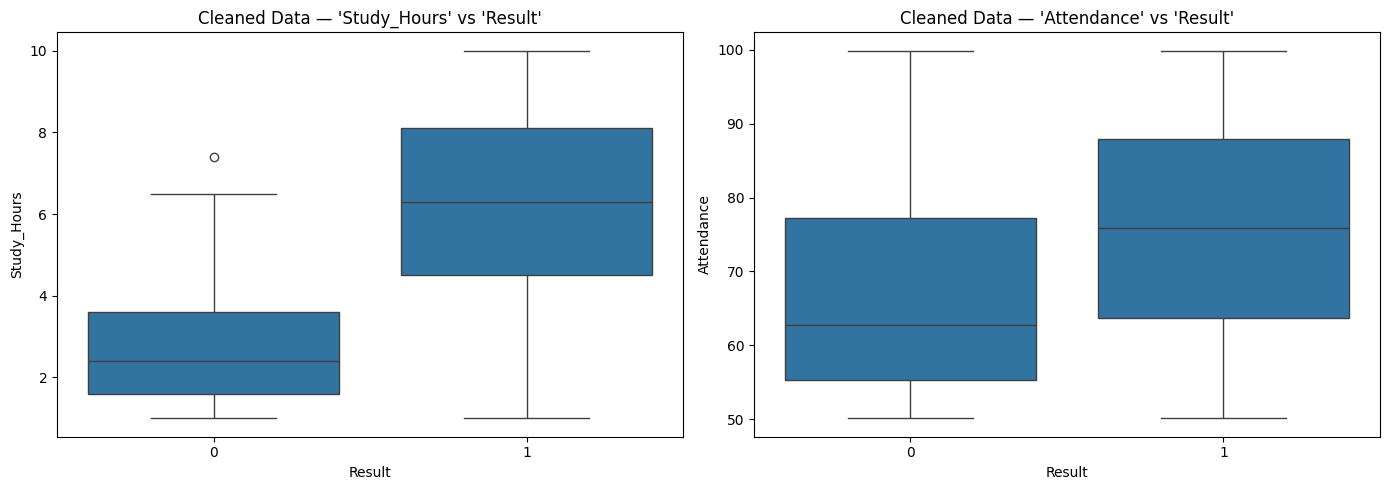

In [93]:
# Boxplot distribution w.r.t Independant Features/ Numerical_Columns and Engineered_Columns and Dependant_Features/ Target_Variables Cateogorical_Columns

# Independant_Features/ Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Engineered_Columns - ["Performance_Index", "Study_Engagement"]

# Dependant_Features/ Categorical_Columns = ["Result"]

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

# "Study_Hours" vs "Result"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)
sns.boxplot(x = "Result",
            y = "Study_Hours",
            data = data3)

plt.title("Cleaned Data — 'Study_Hours' vs 'Result'")

# "Attendance" vs "Result"

plt.subplot(1,2,2)
sns.boxplot(x = "Result",
            y = "Attendance",
            data = data3)

plt.title("Cleaned Data — 'Attendance' vs 'Result'")

plt.tight_layout()
plt.show()

In [94]:
# Even after cleaning, boxplots may still show outliers because:

# Outlier detection is relative to the distribution you’re plotting.
# Grouping by Result changes the distribution, so new outliers can appear.

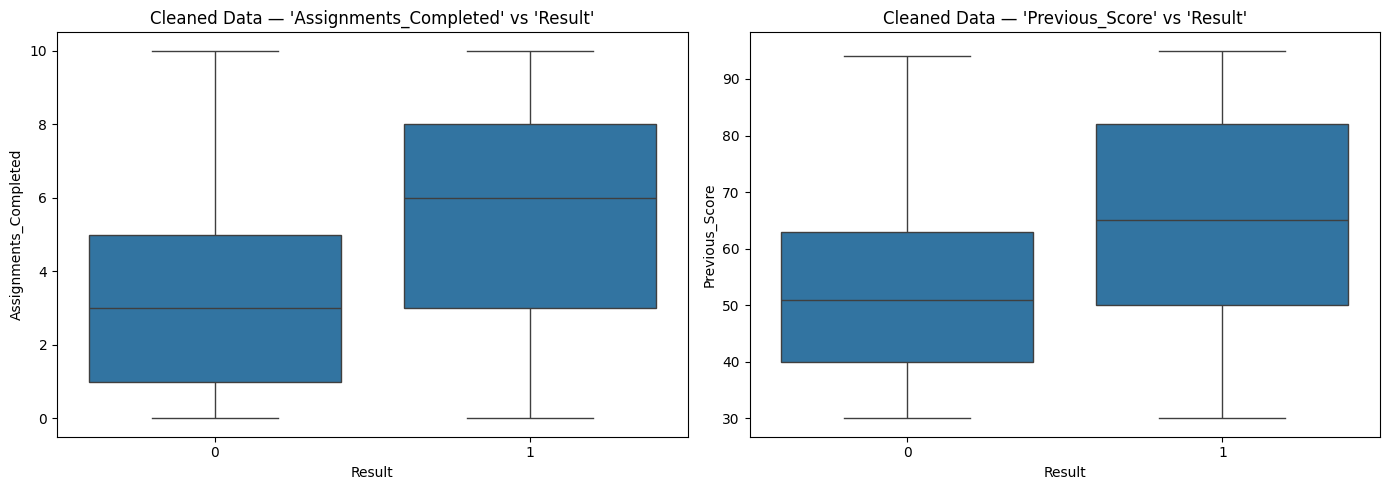

In [95]:
# "Assignments_Completed"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)
sns.boxplot(x = "Result",
            y = "Assignments_Completed",
            data = data3)

plt.title("Cleaned Data — 'Assignments_Completed' vs 'Result'")

# "Previous_Score"

plt.subplot(1,2,2)
sns.boxplot(x = "Result",
            y = "Previous_Score",
            data = data3)

plt.title("Cleaned Data — 'Previous_Score' vs 'Result'")

plt.tight_layout()
plt.show()

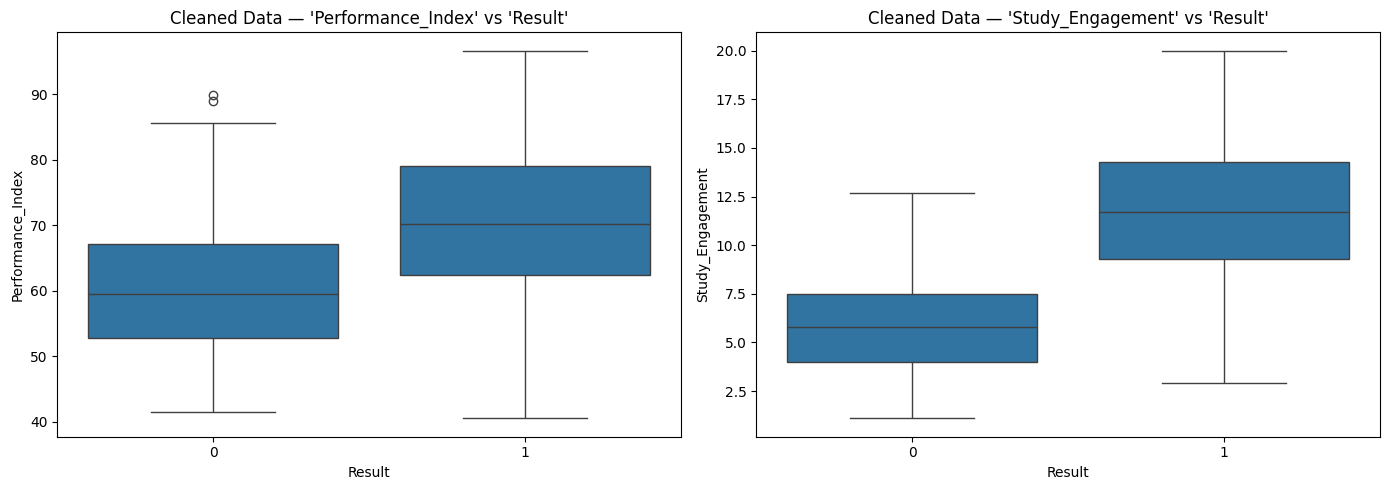

In [96]:
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]

Engineered_Columns = ["Performance_Index", "Study_Engagement"]

# "Performance_Index"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)
sns.boxplot(x = "Result",
            y = "Performance_Index",
            data = data3)

plt.title("Cleaned Data — 'Performance_Index' vs 'Result'")

# "Study_Engagement"

plt.subplot(1,2,2)
sns.boxplot(x = "Result",
            y = "Study_Engagement",
            data = data3)

plt.title("Cleaned Data — 'Study_Engagement' vs 'Result'")

plt.tight_layout()
plt.show()

In [97]:
# All averages w.r.t Dependant_Features/ Target_Variables/ Categorical_Columns

pd.set_option("display.width", 200)
print(data3.groupby("Result")[Numerical_Columns].mean())

        Study_Hours  Attendance  Assignments_Completed  Previous_Score
Result                                                                
0          2.715122   66.766829               3.229268       53.107317
1          6.180503   75.745912               5.613836       64.950943


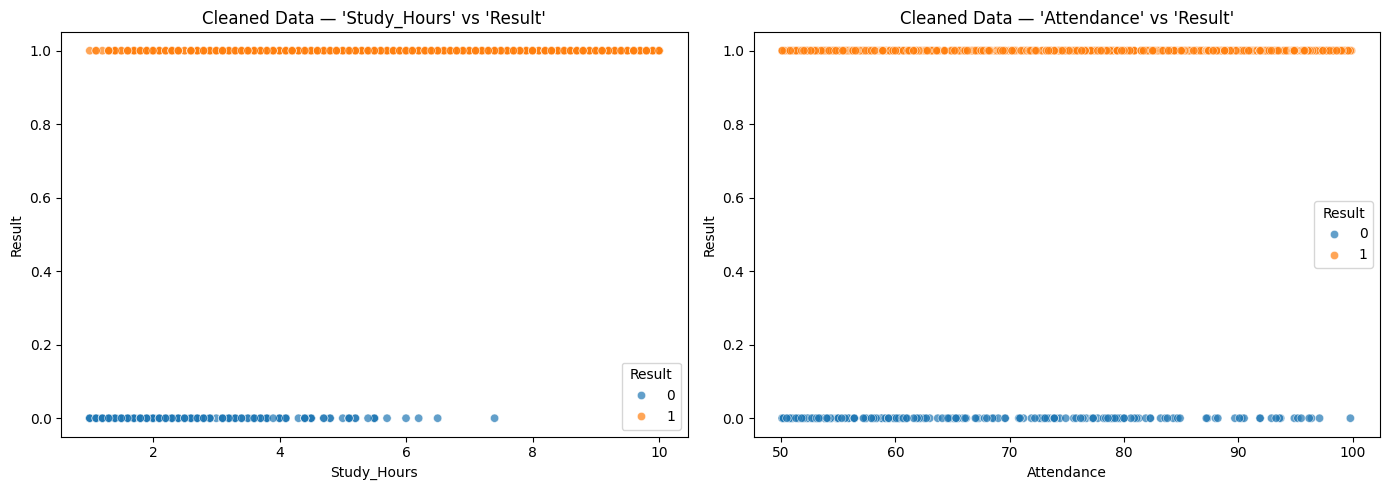

In [98]:
# Scatterplots

# Numerical_Columns/ Independant_Features = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]
# Categorical_Columns/ Dependant_Features = ["Result"]

Numerical_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score"]

# "Study_Hours" vs "Result"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)

plt.title("Cleaned Data — 'Study_Hours' vs 'Result'")
sns.scatterplot(data = data3, x = "Study_Hours", y = "Result", hue = "Result", alpha = 0.7)


# "Attendance" vs "Result"

plt.subplot(1,2,2)

plt.title("Cleaned Data — 'Attendance' vs 'Result'")
sns.scatterplot(data = data3, x = "Attendance", y = "Result", hue = "Result", alpha = 0.7)

plt.tight_layout()
plt.show()

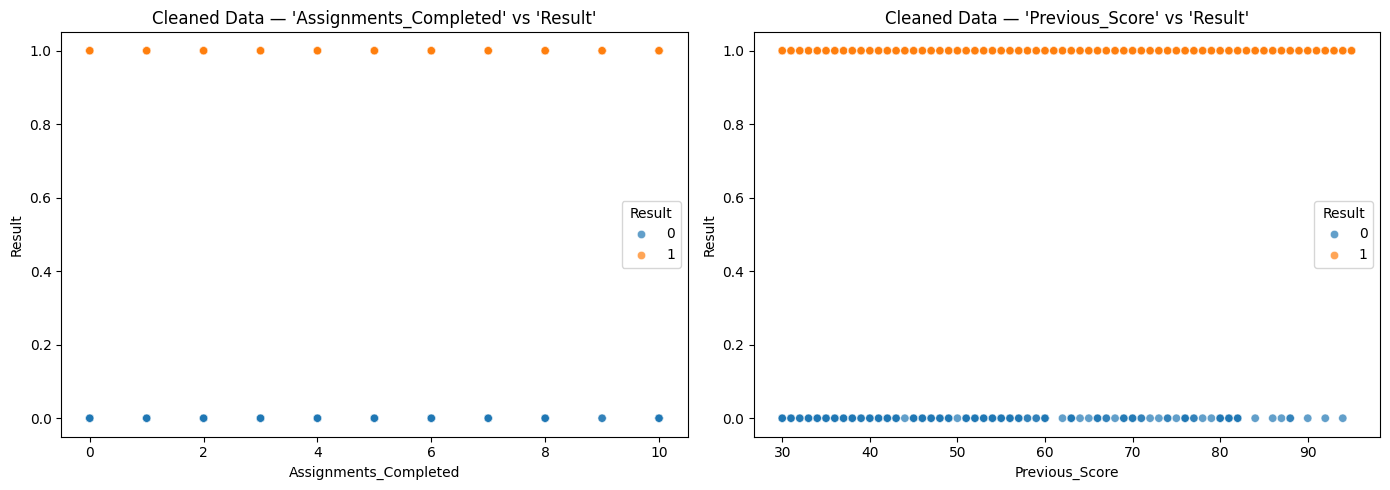

In [99]:
# "Assignments_Completed" vs "Result"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)

plt.title("Cleaned Data — 'Assignments_Completed' vs 'Result'")
sns.scatterplot(data = data3, x = "Assignments_Completed", y = "Result", hue = "Result", alpha = 0.7)

# "Previous_Score" vs "Result"

plt.subplot(1,2,2)

plt.title("Cleaned Data — 'Previous_Score' vs 'Result'")
sns.scatterplot(data = data3, x = "Previous_Score", y = "Result", hue = "Result", alpha = 0.7)

plt.tight_layout()
plt.show()

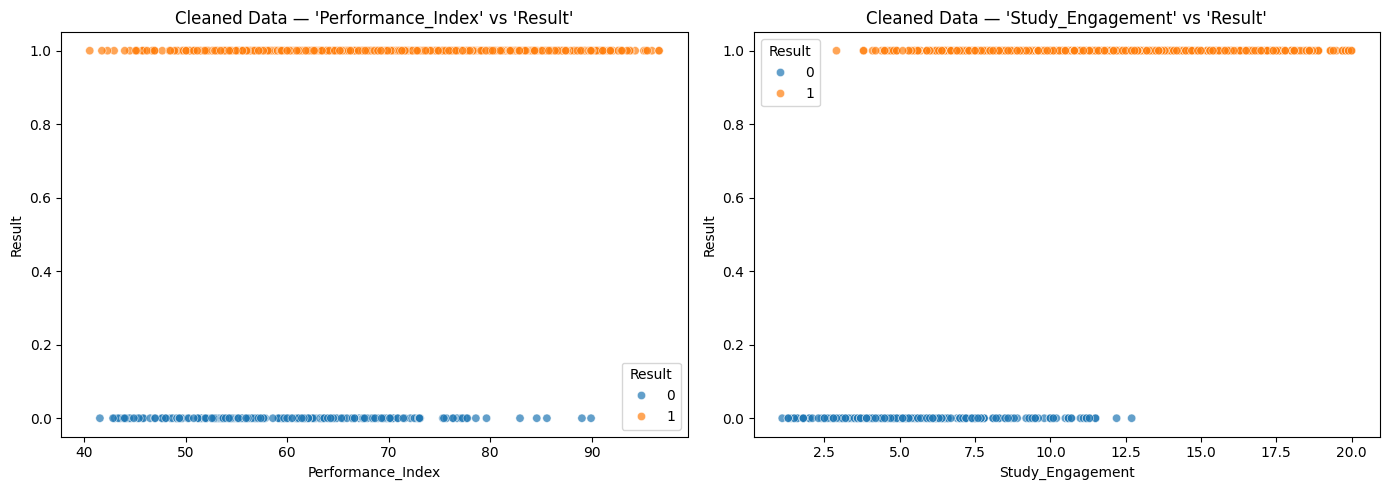

In [100]:
# Engineered_Columns = ["Performance_Index", "Study_Engagement"]

# "Preformance_Index" vs "Result"

plt.figure(figsize = (14, 5))

plt.subplot(1,2,1)

plt.title("Cleaned Data — 'Performance_Index' vs 'Result'")
sns.scatterplot(data = data3, x = "Performance_Index", y = "Result", hue = "Result", alpha = 0.7)

# "Study_Engagement" vs "Result"

plt.subplot(1,2,2)

plt.title("Cleaned Data — 'Study_Engagement' vs 'Result'")
sns.scatterplot(data = data3, x = "Study_Engagement", y = "Result", hue = "Result", alpha = 0.7)

plt.tight_layout()
plt.show()

In [101]:
# Correlation Matrix & Heatmap

correlation_matrix_2 = data3.corr(numeric_only = True)

correlation_matrix_2

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Result,Performance_Index,Study_Engagement
Study_Hours,1.000000,-0.004029,-0.003085,0.083983,0.544831,0.064746,0.630261
Attendance,-0.004029,1.000000,-0.034636,-0.006354,0.253177,0.600063,-0.029440
Assignments_Completed,-0.003085,-0.034636,1.000000,0.010423,0.305499,-0.012622,0.774436
Previous_Score,0.083983,-0.006354,0.010423,1.000000,0.252617,0.796124,0.061225
Result,0.544831,0.253177,0.305499,0.252617,1.000000,0.355295,0.581876
Performance_Index,0.064746,0.600063,-0.012622,0.796124,0.355295,1.000000,0.031162
Study_Engagement,0.630261,-0.029440,0.774436,0.061225,0.581876,0.031162,1.000000


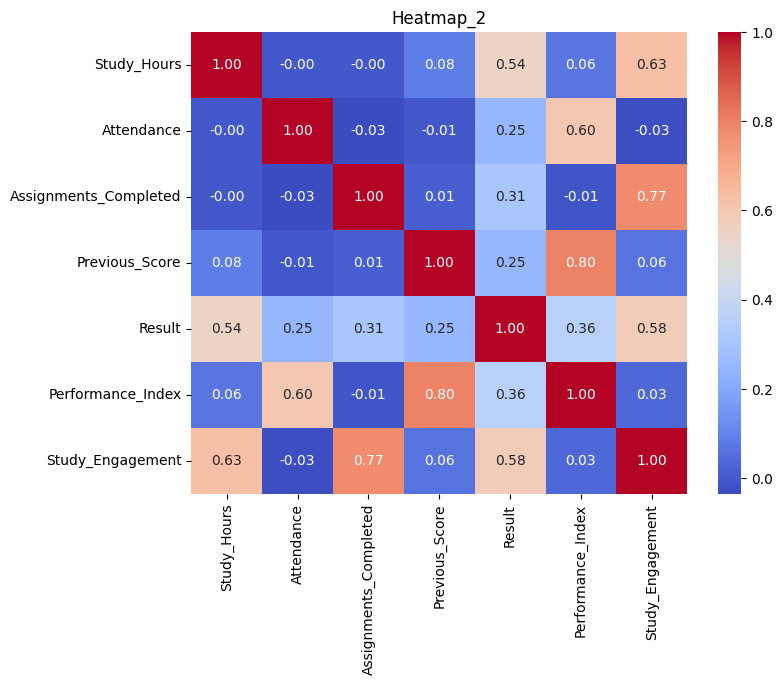

In [102]:
# Creating Heatmap for the Correlation Matrix

plt.figure(figsize = (8, 6))

sns.heatmap(correlation_matrix_2, annot = True, cmap = "coolwarm", fmt = ".2f")

plt.title("Heatmap_2")

plt.show()

In [103]:
# Correlation of each independant feature/ Numerical_Columns w.r.t Dependant_Features/ Target_Variables/ Categorical_Columns

# Study_Hours	0.54
# Attendance	0.25
# Assignments_Completed	0.31
# Previous_Score	0.25
# Performance_Index 0.36
# Study_Engagement 0.58

In [104]:
# Splitting the dataset

# Seperate into input & output variables (i.e) independant features & dependant features (i.e) X & y

# X = data3[["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score", "Performance_Index", "Study_Engagement"]]

# y = data3["Result"]

# Or,

X = data3.drop("Result", axis = 1)

y = data3["Result"]

In [105]:
# Print X

X

,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Performance_Index,Study_Engagement
0,6.3,84.1,0.0,83.0,83.55,6.3
1,2.6,50.3,4.0,76.0,63.15,6.6
2,8.8,65.3,7.0,92.0,78.65,15.8
3,6.8,99.3,5.0,56.0,77.65,11.8
4,1.1,55.9,2.0,82.0,68.95,3.1
...,...,...,...,...,...,...
1015,7.7,78.0,5.0,78.0,78.00,12.7
1016,6.8,61.6,6.0,93.0,77.30,12.8
1017,5.4,73.4,10.0,57.0,65.20,15.4
1018,2.8,93.3,0.0,42.0,67.65,2.8


In [106]:
# Print y

y

,Result
0,1
1,0
2,1
3,1
4,0
...,...
1015,1
1016,1
1017,1
1018,0


In [107]:
# Shape of X & y

print(X.shape)
print(y.shape)
print("Features:", X.columns.to_list())
print("Target:", y.name)

(1000, 6)
(1000,)
Features: ['Study_Hours', 'Attendance', 'Assignments_Completed', 'Previous_Score', 'Performance_Index', 'Study_Engagement']
Target: Result


In [125]:
# Linear Regression

In [126]:
# Train - Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 800
Testing Rows: 200


In [132]:
# Model & Training

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, log_loss, confusion_matrix, classification_report

model = LinearRegression()
model.fit(X_train, y_train)

Linear_Predictions = model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [136]:
# Linear Regression Error Metrics

linear_mae = mean_absolute_error(y_test, Linear_Predictions)
linear_mse = mean_squared_error(y_test, Linear_Predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, Linear_Predictions)

print("Linear Regression Error Metrics:\n")

print(f"MAE  : {linear_mae:.4f}")
print(f"MSE  : {linear_mse:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Error Metrics:

MAE  : 0.2513
MSE  : 0.0844
RMSE : 0.2904
R²   : 0.4824


In [134]:
# Convert Linear Regression predictions into Pass/Fail classes

linear_class_predictions = (linear_predictions >= 0.5).astype(int)

linear_accuracy = accuracy_score(y_test, linear_class_predictions)
linear_error_rate = 1 - linear_accuracy

print("Linear Regression Classification Comparison:\n")
print(f"Accuracy   : {linear_accuracy:.4f} ({linear_accuracy * 100:.2f}%)")
print(f"Error Rate : {linear_error_rate:.4f} ({linear_error_rate * 100:.2f}%)")

Linear Regression Classification Comparison:

Accuracy   : 0.9400 (94.00%)
Error Rate : 0.0600 (6.00%)


In [124]:
# Logistic Regression

In [108]:
# Train - Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 800
Testing Rows: 200


In [109]:
# Scaling - Scale the features

# Logistic Regression is sensitive to feature scale. Fit the scale only on training data to avoid data leakage.

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled.")

Features have been scaled.


In [140]:
# Train the model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, log_loss, confusion_matrix, classification_report

model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train_scaled, y_train)

print("Model has been trained.")

Model has been trained.


In [113]:
# Make predictions

y_pred = model.predict(X_test_scaled)

print("First 20 predictions:", y_pred[:20])

First 20 predictions: [0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1]


In [139]:
# Logistic Regression Error Metrics

logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_error_rate = 1 - logistic_accuracy
logistic_log_loss = log_loss(y_test, y_pred)

print("Logistic Regression Error Metrics:\n")

print(f"Accuracy   : {logistic_accuracy:.4f} ({logistic_accuracy * 100:.2f}%)")
print(f"Error Rate : {logistic_error_rate:.4f} ({logistic_error_rate * 100:.2f}%)")
print(f"Log Loss   : {logistic_log_loss:.4f}")

Logistic Regression Error Metrics:

Accuracy   : 0.9950 (99.50%)
Error Rate : 0.0050 (0.50%)
Log Loss   : 0.1802


In [141]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(confusion_matrix)

Confusion Matrix:

[[ 41   0]
 [  1 158]]


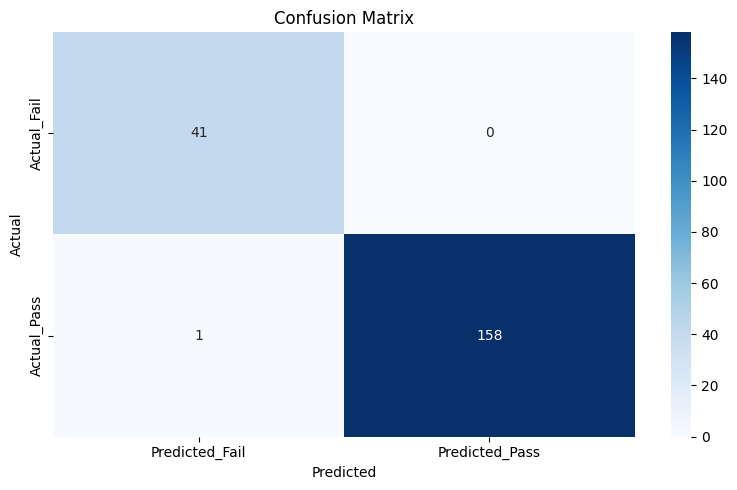

In [142]:
# Plotting the Confusion_Matrix

plt.figure(figsize = (8,5))

sns.heatmap(confusion_matrix, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Predicted_Fail", "Predicted_Pass"],
            yticklabels = ["Actual_Fail", "Actual_Pass"])

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [143]:
# Reading the Confusion_Matrix

# True Negative: Actual 0, Predicted 0
# False Positive: Actual 0, Predicted 1
# False Negative: Actual 1, Predicted 0
# True Positive: Actual 1, Predicted 1

In [144]:
# Classification_Report

from sklearn.metrics import classification_report

print("Classification_Report:\n")
print(classification_report(y_test, y_pred, target_names = ["Fail", "Pass"]))

Classification_Report:

              precision    recall  f1-score   support

        Fail       0.98      1.00      0.99        41
        Pass       1.00      0.99      1.00       159

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [145]:
# Interpret Logistic Regression Coefficients -

# Positive Coefficient - Associated with Pass.
# Negative Coefficient - Associated with Fail.

# Because features were standardized, coefficients are easier to compare.

In [146]:
Feature_Columns = ["Study_Hours", "Attendance", "Assignments_Completed", "Previous_Score", "Performance_Index", "Study_Engagement"]

coefficients = pd.DataFrame({"Feature": Feature_Columns, "Coefficient": model.coef_[0]})

coefficients["Absolute Coefficient Value"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by = "Absolute Coefficient Value", ascending = False)

print("Coefficients:\n\n", coefficients)

Coefficients:

                  Feature  Coefficient  Absolute Coefficient Value
0            Study_Hours     4.213980                    4.213980
5       Study_Engagement     3.318000                    3.318000
4      Performance_Index     1.787403                    1.787403
1             Attendance     1.615545                    1.615545
3         Previous_Score     1.040512                    1.040512
2  Assignments_Completed     0.875918                    0.875918


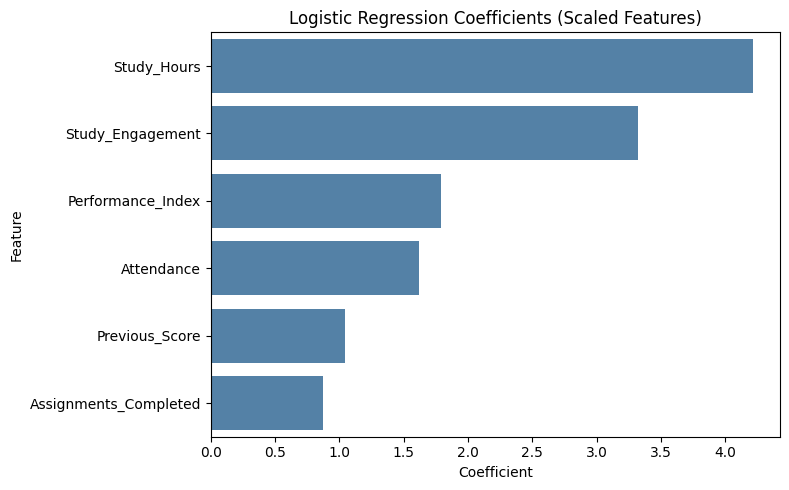

In [147]:
# Plot the Coefficients

plt.figure(figsize = (8,5))

sns.barplot(data = coefficients, x = "Coefficient", y = "Feature", color = "steelblue")

plt.title("Logistic Regression Coefficients (Scaled Features)")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [148]:
# A +ve Coefficient means that as the feature value increases, the student is more likely to pass.
# A -ve Coefficient means that as the feature value increases, the student is less likely to pass or more likely to fail.

In [151]:
# Model Comparison

comparison = pd.DataFrame({"Model": ["Linear Regression", "Logistic Regression"],
                           "Accuracy": [linear_accuracy, logistic_accuracy],
                           "Error_Rate": [linear_error_rate, logistic_error_rate],
                           "MAE": [linear_mae, np.nan],
                           "MSE": [linear_mse, np.nan],
                           "RMSE": [linear_rmse, np.nan],
                           "R2": [linear_r2, np.nan],
                           "Log_Loss": [np.nan, logistic_log_loss]})

print(comparison)

                 Model  Accuracy  Error_Rate       MAE       MSE      RMSE        R2  Log_Loss
0    Linear Regression     0.940       0.060  0.251256  0.084356  0.290441  0.482399       NaN
1  Logistic Regression     0.995       0.005       NaN       NaN       NaN       NaN  0.180218


In [150]:
print("Final Model Results:\n")

print(f"Linear Regression Accuracy : {linear_accuracy * 100:.2f}%")
print(f"Linear Regression Error    : {linear_error_rate * 100:.2f}%")
print(f"Linear Regression MAE      : {linear_mae:.4f}")
print(f"Linear Regression MSE      : {linear_mse:.4f}")
print(f"Linear Regression RMSE     : {linear_rmse:.4f}")
print(f"Linear Regression R²       : {linear_r2:.4f}")
print()
print(f"Logistic Regression Accuracy : {logistic_accuracy * 100:.2f}%")
print(f"Logistic Regression Error    : {logistic_error_rate * 100:.2f}%")
print(f"Logistic Regression Log Loss : {logistic_log_loss:.4f}")

Final Model Results:

Linear Regression Accuracy : 94.00%
Linear Regression Error    : 6.00%
Linear Regression MAE      : 0.2513
Linear Regression MSE      : 0.0844
Linear Regression RMSE     : 0.2904
Linear Regression R²       : 0.4824

Logistic Regression Accuracy : 99.50%
Logistic Regression Error    : 0.50%
Logistic Regression Log Loss : 0.1802
